In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
def analyze_hyperparameters(directory_path, plot_show=True, threshold=0.5):
    """
    Searches for a single CSV file in the given directory, performs analysis,
    generates visualizations, and saves the plots to a dedicated 'analysis_output'
    folder within that same directory.

    Args:
        directory_path (str): The path to the directory containing the CSV file.
        plot_show (bool): If True, displays the plots interactively.
        threshold (float): The value to subtract from the max accuracy to define
                         high-performing models for the summary.
    """
    # --- 1. Find the CSV file ---
    csv_files = glob.glob(os.path.join(directory_path, '*.csv'))

    if len(csv_files) == 1:
        file_path = csv_files[0]
        #print(f"Found CSV file: {file_path}")
    elif len(csv_files) == 0:
        print(f"Error: No CSV files found in '{directory_path}'.")
        return
    else:
        print(f"Error: More than one CSV file found in '{directory_path}'. Please ensure there is only one.")
        print("Found files:", csv_files)
        return

    # --- 2. Define and Create Output Directory ---
    output_dir = os.path.join(directory_path, 'analysis_output')
    os.makedirs(output_dir, exist_ok=True)
    print(f"\nOutput will be saved to: {output_dir}")

    # --- 3. Load Data ---
    try:
        df = pd.read_csv(file_path)
        #print(f"Successfully loaded data from '{file_path}'")
    except FileNotFoundError:
        # This is a fallback, though the glob check should prevent it.
        print(f"Error: The file '{file_path}' was not found.")
        return

    # --- 4. Correlation Analysis ---
    columns_to_correlate = ['gap', 'seq_num', 'hidden_size', 'num_layer', 'ACC']
    corr_matrix = df[columns_to_correlate].corr(method='spearman')

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm',
        fmt=".2f",
        linewidths=.5
    )
    plt.title('Spearman Correlation Matrix of Parameters and Accuracy', fontsize=16)

    corr_save_path = os.path.join(output_dir, 'correlation_matrix.png')
    plt.savefig(corr_save_path, dpi=300, bbox_inches='tight')
    #print(f"Correlation matrix saved to '{corr_save_path}'")
    if plot_show:
        plt.show()
    else:
        plt.close()

    # --- 5. Visualize Impact of Window Size (seq_num) ---
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 14))
    fig.suptitle('Impact of Window Size on Accuracy', fontsize=20)

    boxplot_props = {
        "showmeans": True,
        "meanprops": {
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": "8"
        }
    }

    # Plot 1: Overall impact
    sns.boxplot(ax=axes[0, 0], x='seq_num', y='ACC', data=df, **boxplot_props)
    axes[0, 0].set_xlabel('Window Size', fontsize=14)
    axes[0, 0].set_ylabel('Accuracy (%)', fontsize=14)
    axes[0, 0].grid(True, axis='y')

    # Plot 2: Grouped by Gap
    sns.boxplot(ax=axes[0, 1], x='seq_num', y='ACC', hue='gap', data=df, **boxplot_props)
    axes[0, 1].set_xlabel('Window Size', fontsize=14)
    axes[0, 1].set_ylabel('')
    axes[0, 1].grid(True, axis='y')
    axes[0, 1].legend(title='Gap')

    # Plot 3: Grouped by Hidden Size
    sns.boxplot(ax=axes[1, 0], x='seq_num', y='ACC', hue='hidden_size', data=df, **boxplot_props)
    axes[1, 0].set_xlabel('Window Size', fontsize=14)
    axes[1, 0].set_ylabel('Accuracy (%)', fontsize=14)
    axes[1, 0].grid(True, axis='y')
    axes[1, 0].legend(title='Hidden Size')

    # Plot 4: Grouped by Number of Layers
    sns.boxplot(ax=axes[1, 1], x='seq_num', y='ACC', hue='num_layer', data=df, **boxplot_props)
    axes[1, 1].set_xlabel('Window Size', fontsize=14)
    axes[1, 1].set_ylabel('')
    axes[1, 1].grid(True, axis='y')
    axes[1, 1].legend(title='Num Layers')

    for ax in axes.flatten():
        ax.tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    impact_save_path = os.path.join(output_dir, 'window_size_impact.png')
    plt.savefig(impact_save_path, dpi=300, bbox_inches='tight')
    #print(f"Window size impact plot saved to '{impact_save_path}'")
    if plot_show:
        plt.show()
    else:
        plt.close()


    # --- 6. Summary Statistics ---
    high_accuracy_threshold = df.ACC.max() - threshold
    num_high_performers = df.loc[df.ACC > high_accuracy_threshold].shape[0]
    print(f"{num_high_performers} models reached accuracy over {high_accuracy_threshold:.2f}%. Highest Accuracy Recorded: {df.ACC.max():.4f}%")

    print(df.loc[df.ACC > high_accuracy_threshold])



def analyze_hyper_transformer(directory_path, plot_show=True, threshold=0.5):
    """
    Searches for a single hyperparameter results CSV file in the given directory,
    performs analysis tailored for the Transformer model, generates visualizations,
    and saves the plots to a dedicated 'analysis_output' folder.

    Args:
        directory_path (str): The path to the directory containing the CSV file.
        plot_show (bool): If True, displays the plots interactively.
        threshold (float): The value to subtract from the max accuracy to define
                           high-performing models for the summary.
    """
    # --- 1. Find the CSV file ---
    csv_files = glob.glob(os.path.join(directory_path, '*.csv'))

    if len(csv_files) == 1:
        file_path = csv_files[0]
    elif len(csv_files) == 0:
        print(f"Error: No CSV files found in '{directory_path}'.")
        return
    else:
        print(f"Error: More than one CSV file found in '{directory_path}'. Please ensure there is only one.")
        print("Found files:", csv_files)
        return

    # --- 2. Define and Create Output Directory ---
    output_dir = os.path.join(directory_path, 'analysis_output')
    os.makedirs(output_dir, exist_ok=True)
    print(f"\nAnalysis output will be saved to: {output_dir}")

    # --- 3. Load Data ---
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return
    
    # Drop the 'dropout' column if it exists to clean the data
    if 'dropout' in df.columns:
        df.drop('dropout', axis=1, inplace=True)
    if 'weight_decay' in df.columns:
        df.drop('weight_decay', axis=1, inplace=True)
    if 'learning_rate' in df.columns:
        df.drop('learning_rate', axis=1, inplace=True)

    # --- 4. Correlation Analysis ---
    # ✅ CHANGED: Updated columns for Transformer hyperparameters
    columns_to_correlate = ['seq_num','d_model', 'n_head', 'num_layer', 'ACC']
    
    # Ensure all columns exist before trying to correlate
    valid_columns = [col for col in columns_to_correlate if col in df.columns]
    corr_matrix = df[valid_columns].corr(method='spearman')

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm',
        fmt=".2f",
        linewidths=.5
    )
    plt.title('Spearman Correlation Matrix of Transformer Parameters and Accuracy', fontsize=16)

    corr_save_path = os.path.join(output_dir, 'correlation_matrix.png')
    plt.savefig(corr_save_path, dpi=300, bbox_inches='tight')
    if plot_show:
        plt.show()
    else:
        plt.close()

    # --- 5. Visualize Impact of Window Size (seq_num) ---
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 14))
    fig.suptitle('Impact of Key Hyperparameters on Accuracy', fontsize=20)

    boxplot_props = {
        "showmeans": True,
        "meanprops": {
            "marker": "o", "markerfacecolor": "white",
            "markeredgecolor": "black", "markersize": "8"
        }
    }
    '''plot_variables = ['seq_num', 'num_layer', 'd_model', 'n_head']
    legend = ['Window Size', 'Encoder Layers', 'Embedding Dimention', 'Attention Heads']
    x_axes = 'seq_num'
    x_name = 'Window time steps'
    y_axes = 'ACC'
    y_name = 'Accuracy (%)'
    counter = 0
    for i in [0, 1]:
        for j in [0, 1]: 
            sns.boxplot(ax=axes[i, j], x=x_axes, y=y_axes, hue=plot_variables[counter], data=df, **boxplot_props)
            axes[i, j].set_xlabel(x_name, fontsize=14)
            axes[i, j].set_ylabel(y_name, fontsize=14)
            axes[i, j].grid(True, axis='y')
            axes[i, j].legend(title=legend[counter])
            counter +=1
    plt.show()
'''

    # Plot 1: Overall impact of window size
    sns.boxplot(ax=axes[0, 0], x='num_layer', y='ACC', data=df, **boxplot_props)
    axes[0, 0].set_xlabel('Number of Layers', fontsize=14)
    axes[0, 0].set_ylabel('Accuracy (%)', fontsize=14)
    axes[0, 0].grid(True, axis='y')

    # Plot 2: Grouped by Model Dimension (d_model)
    # ✅ CHANGED: Replaced 'hidden_size' with 'd_model'
    sns.boxplot(ax=axes[0, 1], x='num_layer', y='ACC', hue='d_model', data=df, **boxplot_props)
    axes[0, 1].set_xlabel('Number of Layers', fontsize=14)
    axes[0, 1].set_ylabel('')
    axes[0, 1].grid(True, axis='y')
    axes[0, 1].legend(title='d_model')

    # Plot 3: Grouped by Number of Attention Heads (n_head)
    # ✅ CHANGED: Replaced 'hidden_size' plot with 'n_head' plot
    sns.boxplot(ax=axes[1, 0], x='num_layer', y='ACC', hue='n_head', data=df, **boxplot_props)
    axes[1, 0].set_xlabel('Number of Layers', fontsize=14)
    axes[1, 0].set_ylabel('Accuracy (%)', fontsize=14)
    axes[1, 0].grid(True, axis='y')
    axes[1, 0].legend(title='n_head')

    # Plot 4: Grouped by Number of Attention Heads (n_head)
    # ✅ CHANGED: Replaced 'hidden_size' plot with 'seq_num' plot
    sns.boxplot(ax=axes[1, 1], x='num_layer', y='ACC', hue='seq_num', data=df, **boxplot_props)
    axes[1, 1].set_xlabel('Number of Layers', fontsize=14)
    axes[1, 1].set_ylabel('Accuracy (%)', fontsize=14)
    axes[1, 1].grid(True, axis='y')
    axes[1, 1].legend(title='Window Size')
    for ax in axes.flatten():
        ax.tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    impact_save_path = os.path.join(output_dir, 'hyperparameter_impact.png')
    plt.savefig(impact_save_path, dpi=300, bbox_inches='tight')
    if plot_show:
        plt.show()
    else:
        plt.close()


    # --- 6. Summary Statistics ---
    if not df.empty and 'ACC' in df.columns:
        max_acc = df.ACC.max()
        high_accuracy_threshold = max_acc - threshold
        high_performers_df = df.loc[df.ACC >= high_accuracy_threshold].sort_values(by='ACC', ascending=False)
        
        print("\n" + "="*50)
        print("HYPERPARAMETER ANALYSIS SUMMARY")
        print("="*50)
        print(f"Highest Accuracy Recorded: {max_acc:.4f}%")
        print(f"\nDisplaying {len(high_performers_df)} models with accuracy >= {high_accuracy_threshold:.2f}%:")
        print(high_performers_df.to_string())
    else:
        print("\nCould not generate summary statistics. DataFrame might be empty or missing 'ACC' column.")




# Source Robot: Franka_main


Output will be saved to: trained_models/franka_main/m2_cnnBiLSTM_contactDetection/64/analysis_output


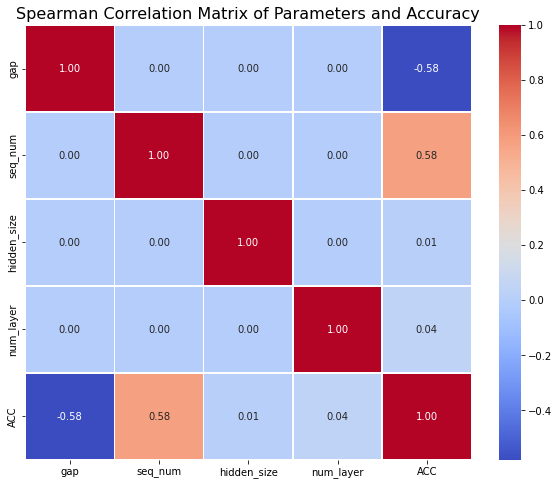

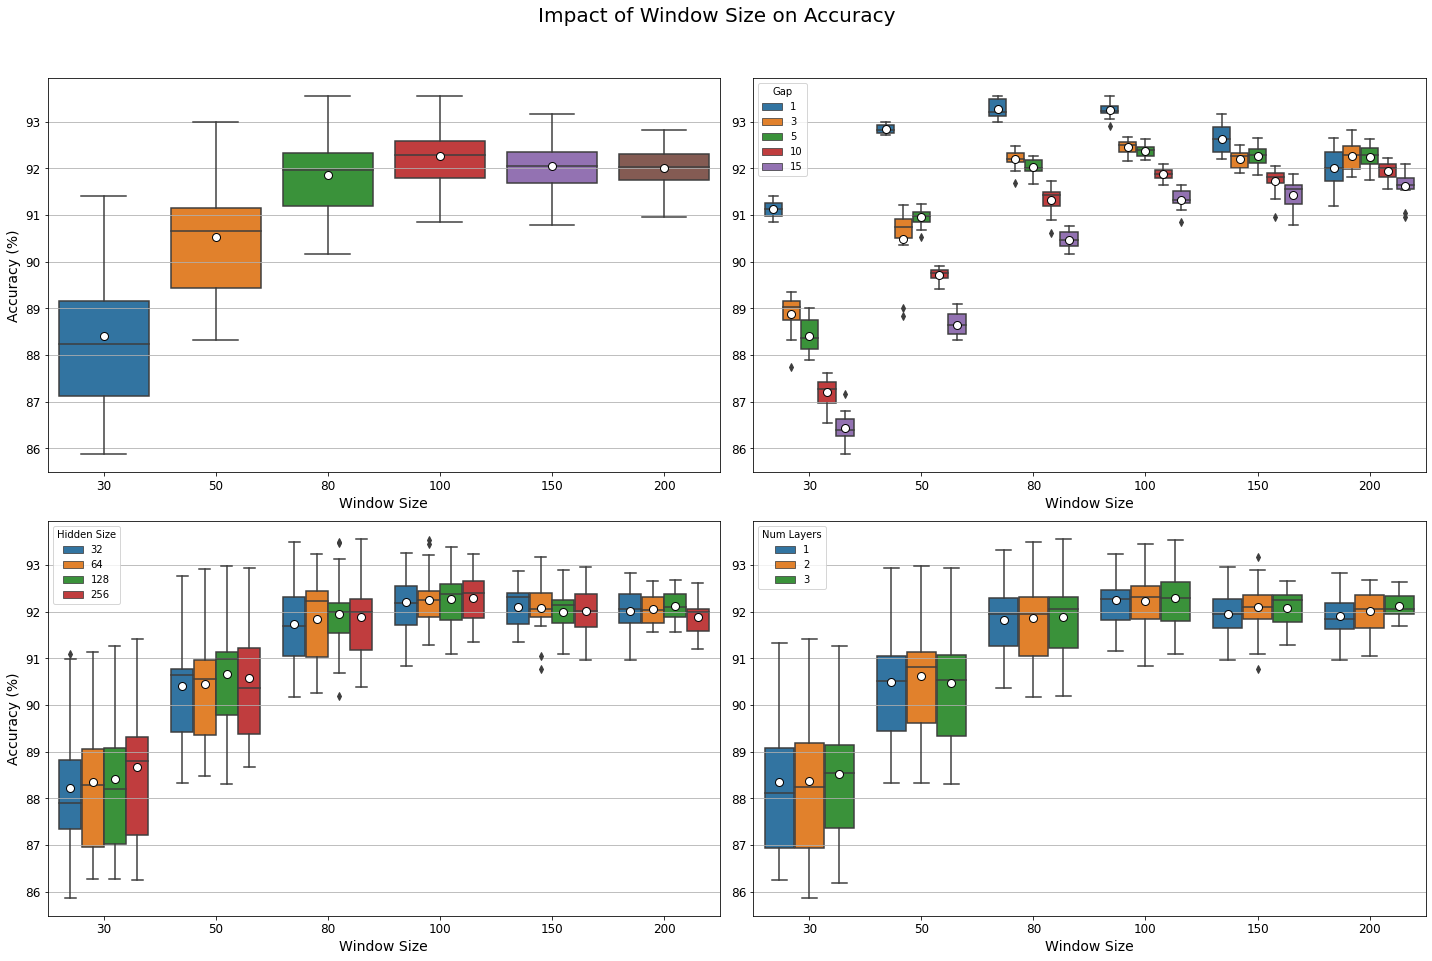

7 models reached accuracy over 93.35%. Highest Accuracy Recorded: 93.5544%
     gap  seq_num  hidden_size  num_layer        ACC  train_size  val_size
313    1       80           32          2  93.502703     1083137    104505
319    1       80          128          2  93.486436     1083137    104505
320    1       80          128          3  93.472083     1083137    104505
323    1       80          256          3  93.554375     1083137    104505
328    1      100           64          2  93.452747     1073117    102501
329    1      100           64          3  93.542502     1073117    102501
332    1      100          128          3  93.386406     1073117    102501

Analysis output will be saved to: trained_models/franka_main/m2_transformer_contactDetection/64/analysis_output


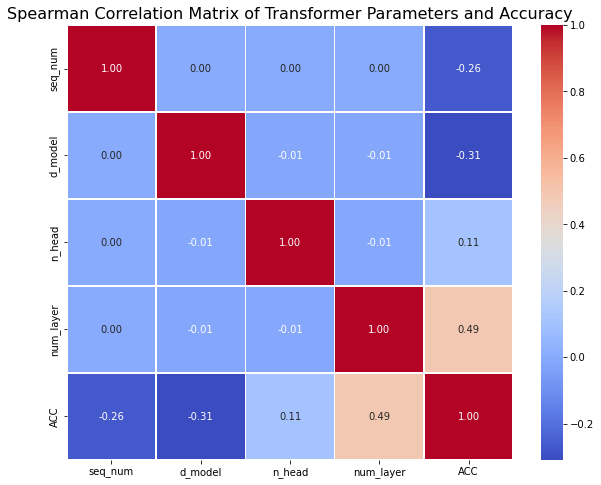

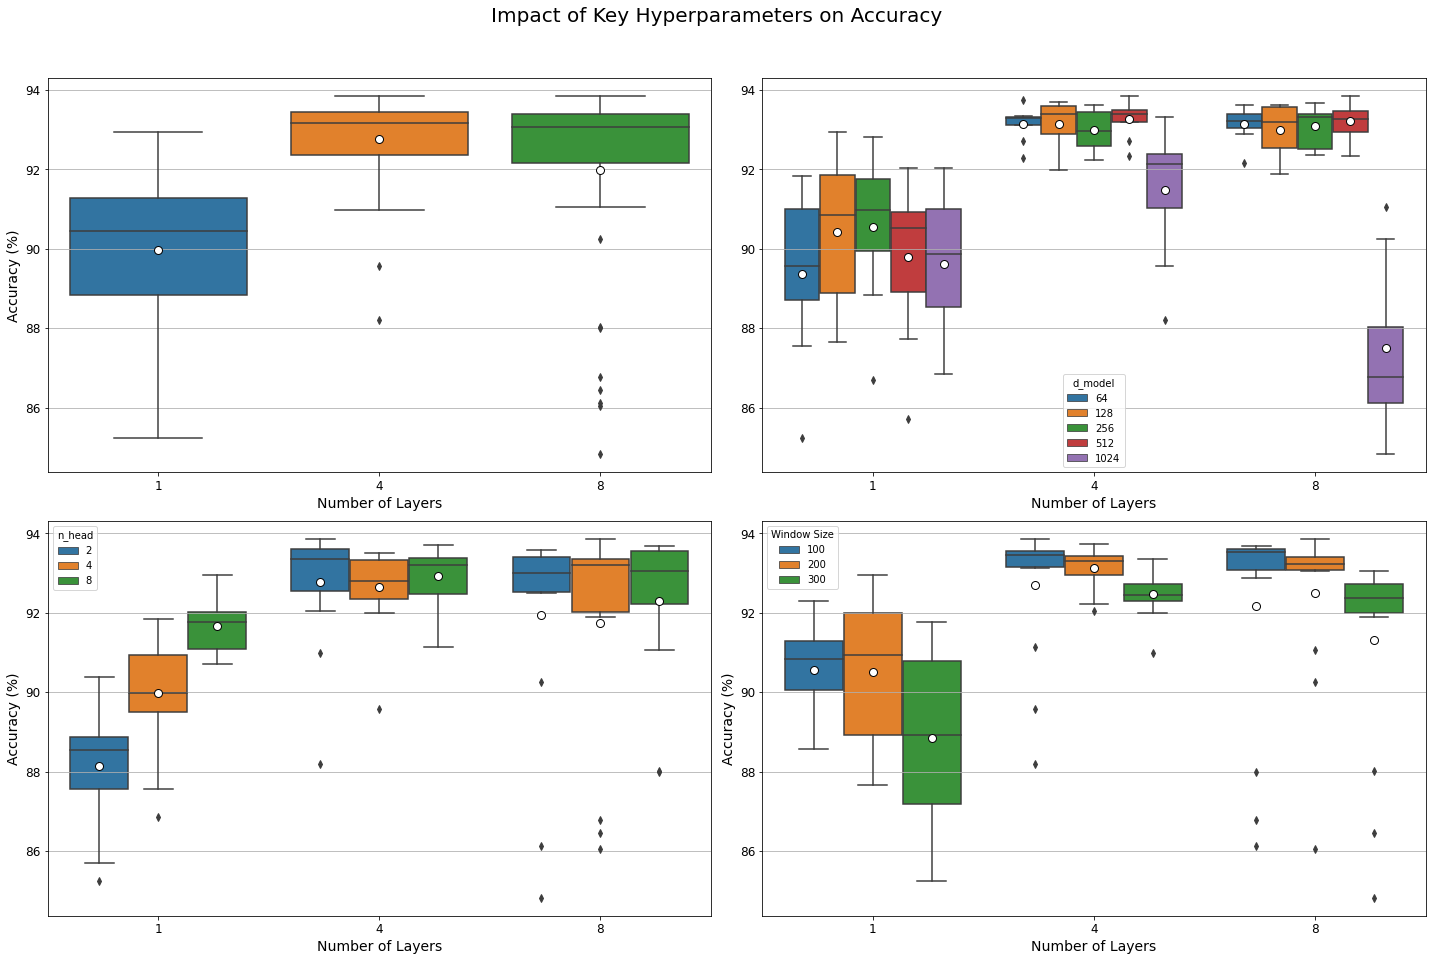


HYPERPARAMETER ANALYSIS SUMMARY
Highest Accuracy Recorded: 93.8560%

Displaying 6 models with accuracy >= 93.66%:
    seq_num  d_model  n_head  num_layer        ACC
76      200      512       4          8  93.856035
28      100      512       2          4  93.855947
45      200       64       2          4  93.743580
60      200      128       8          4  93.711141
26      100      256       8          8  93.686647
35      100      512       8          8  93.671985


In [2]:
#analyze_hyperparameters(directory_path='trained_models/franka_main/m1_cnnBiLSTM_contactDetection', plot_show= False, threshold=0.05)
analyze_hyperparameters(directory_path='trained_models/franka_main/m2_cnnBiLSTM_contactDetection/64', plot_show= True, threshold=0.2)
analyze_hyper_transformer(directory_path='trained_models/franka_main/m2_transformer_contactDetection/64', plot_show= True, threshold=0.2)


Output will be saved to: trained_models/franka_main/m2_cnnBiLSTM_contactLocalization/64/analysis_output


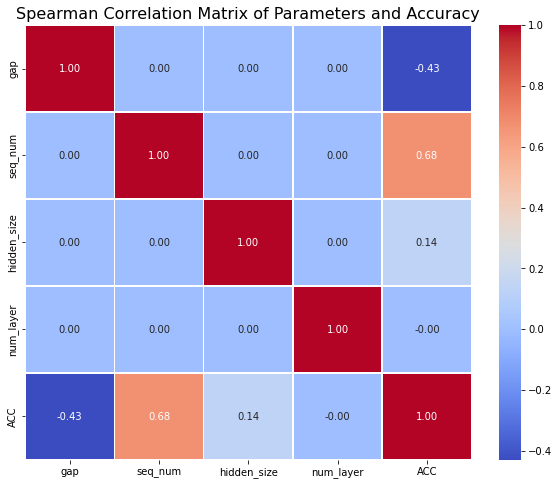

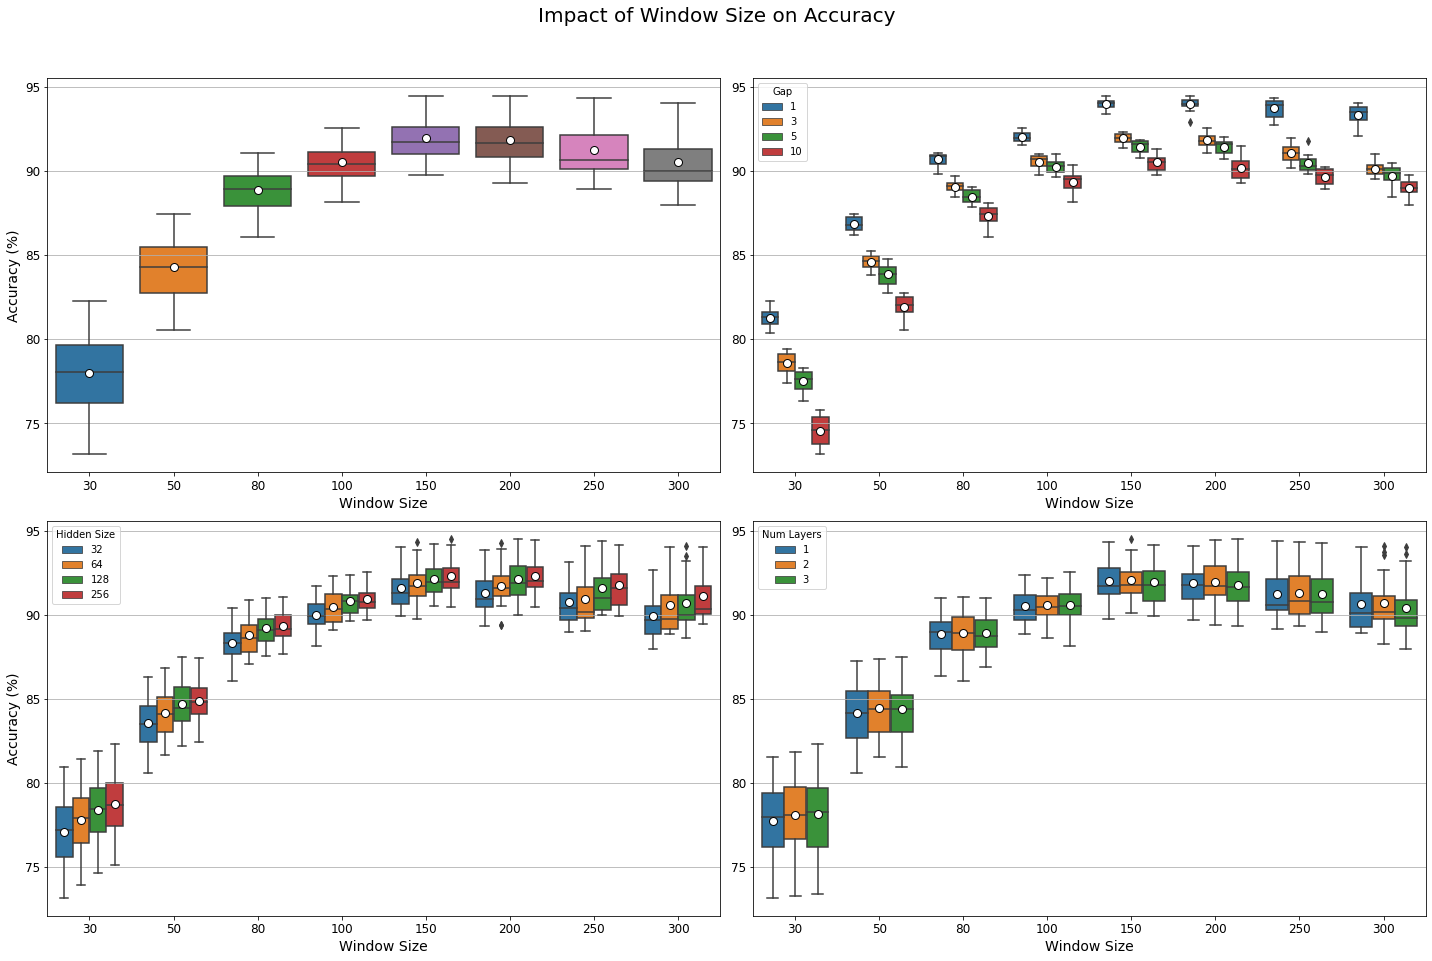

6 models reached accuracy over 94.29%. Highest Accuracy Recorded: 94.4918%
    seq_num  gap  hidden_size  num_layer        ACC  train_size  val_size
51      150    1           64          1  94.326603      497463     41157
58      150    1          256          2  94.491824      497463     41157
68      200    1          128          3  94.488828      497194     38177
70      200    1          256          2  94.425963      497194     38177
78      250    1          128          1  94.383709      496312     35308
79      250    1          128          2  94.321400      496312     35308

Analysis output will be saved to: trained_models/franka_main/m2_transformer_contactLocalization/64/analysis_output


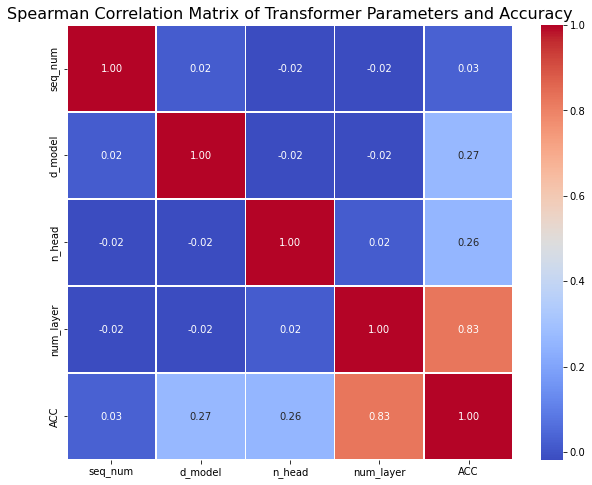

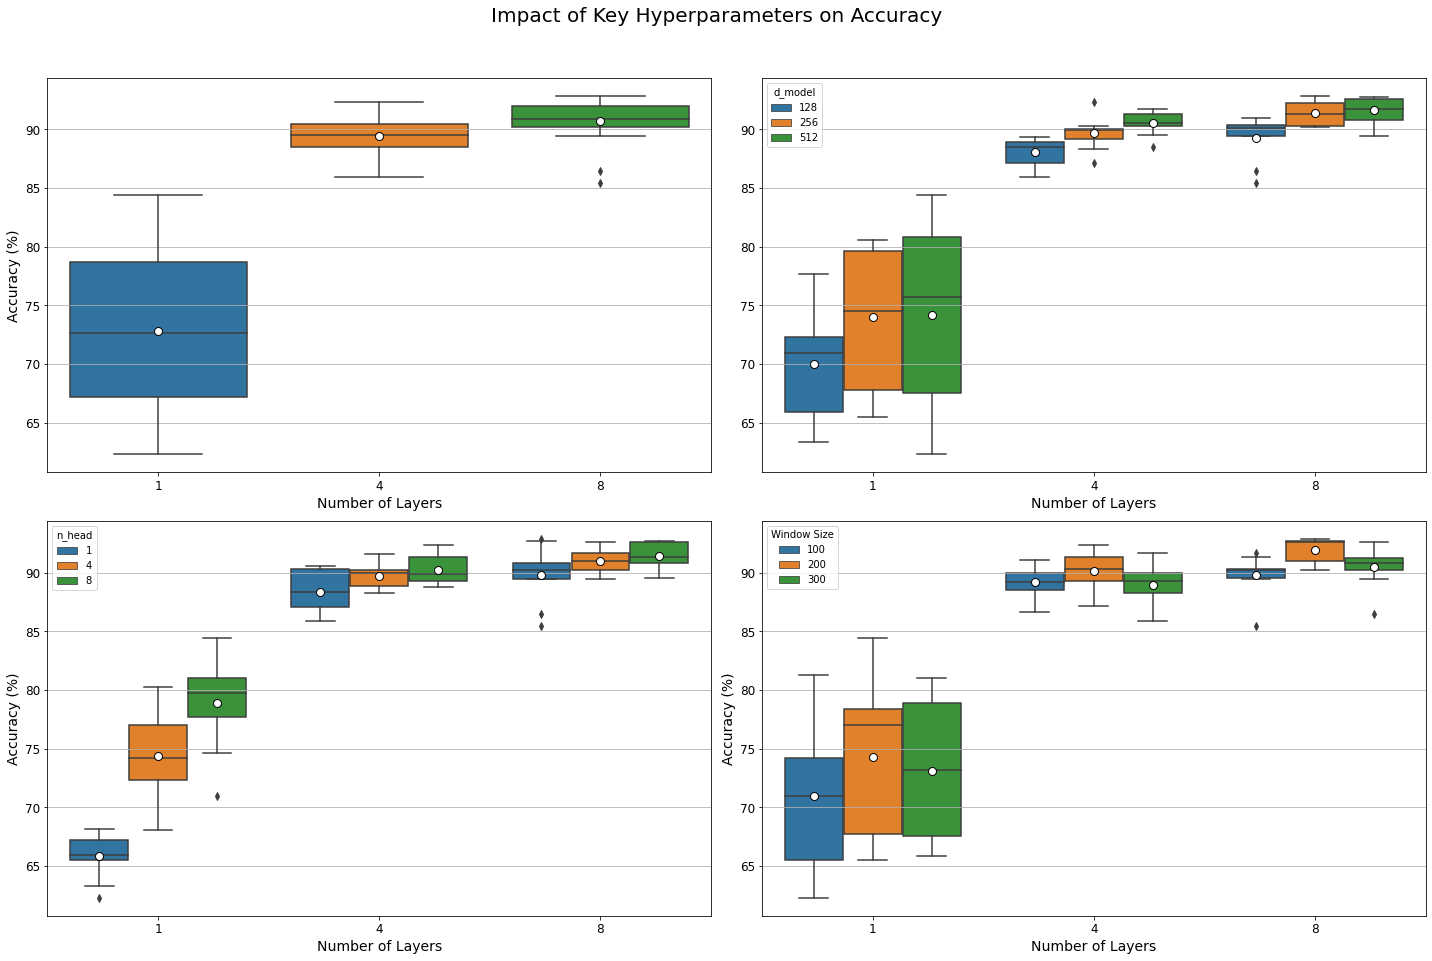


HYPERPARAMETER ANALYSIS SUMMARY
Highest Accuracy Recorded: 92.8648%

Displaying 6 models with accuracy >= 92.56%:
    seq_num  gap  d_model  n_head  num_layer        ACC  train_size  val_size
38      200    1      256       1          8  92.864814     1023017     92481
53      200    1      512       8          8  92.718129     1023017     92481
47      200    1      512       1          8  92.710271     1023017     92481
50      200    1      512       4          8  92.629070     1023017     92481
81      300    1      512       8          8  92.604650      972917     82461
44      200    1      256       8          8  92.581921     1023017     92481


In [3]:
#analyze_hyperparameters(directory_path='trained_models/franka_main/m1_cnnBiLSTM_contactLocalization', plot_show= False, threshold=0.08)
analyze_hyperparameters(directory_path='trained_models/franka_main/m2_cnnBiLSTM_contactLocalization/64', plot_show= True, threshold=0.2)
analyze_hyper_transformer(directory_path='trained_models/franka_main/m2_transformer_contactLocalization/64', plot_show= True, threshold=0.3)

# Target Robot: Franka_Mindlab


Output will be saved to: trained_models/franka_mindlab/m2_cnnBiLSTM_contactDetection/64/analysis_output


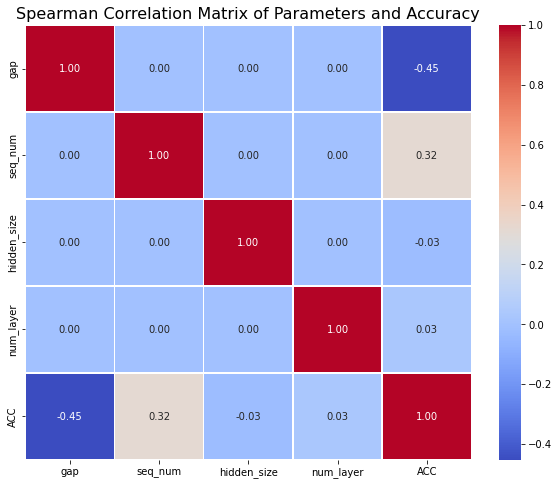

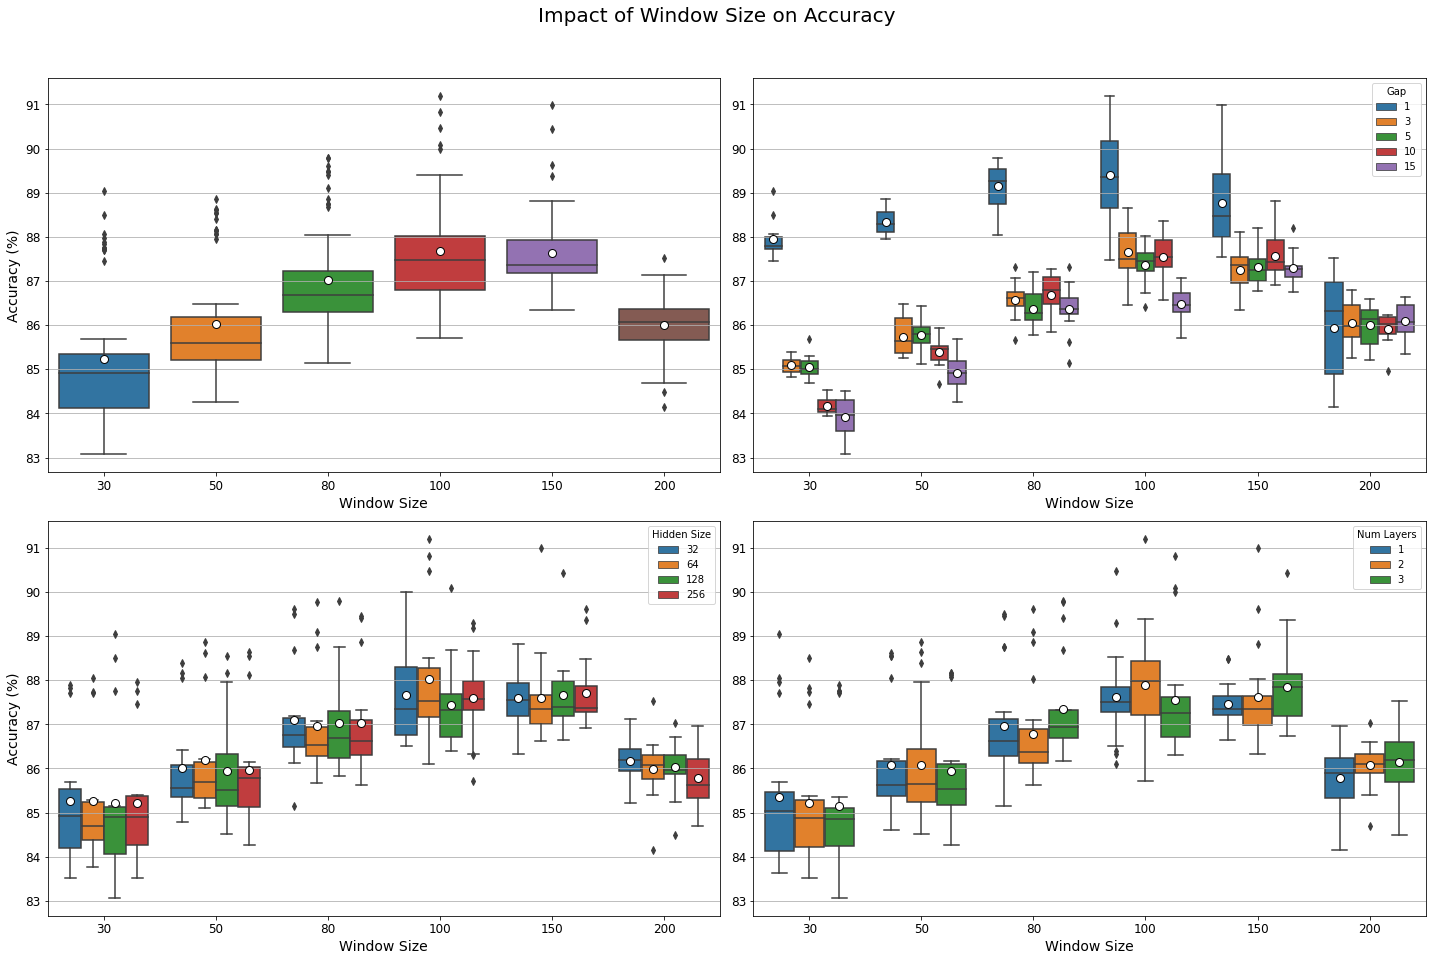

1 models reached accuracy over 90.99%. Highest Accuracy Recorded: 91.1945%
    gap  seq_num  hidden_size  num_layer        ACC  train_size  val_size
40    1      100           64          2  91.194501       55850      5383

Analysis output will be saved to: trained_models/franka_mindlab/m2_transformer_contactDetection/64/analysis_output


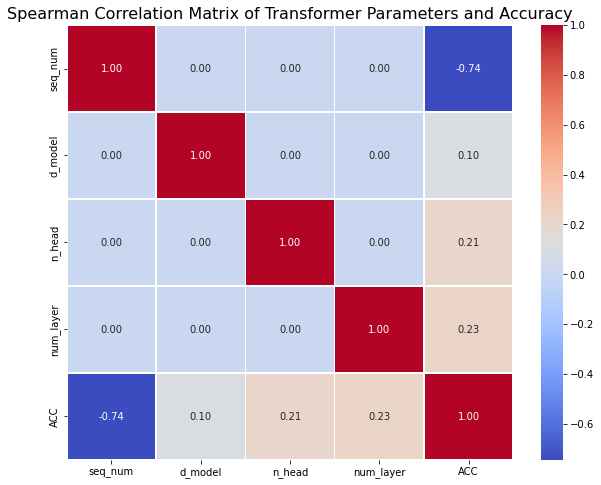

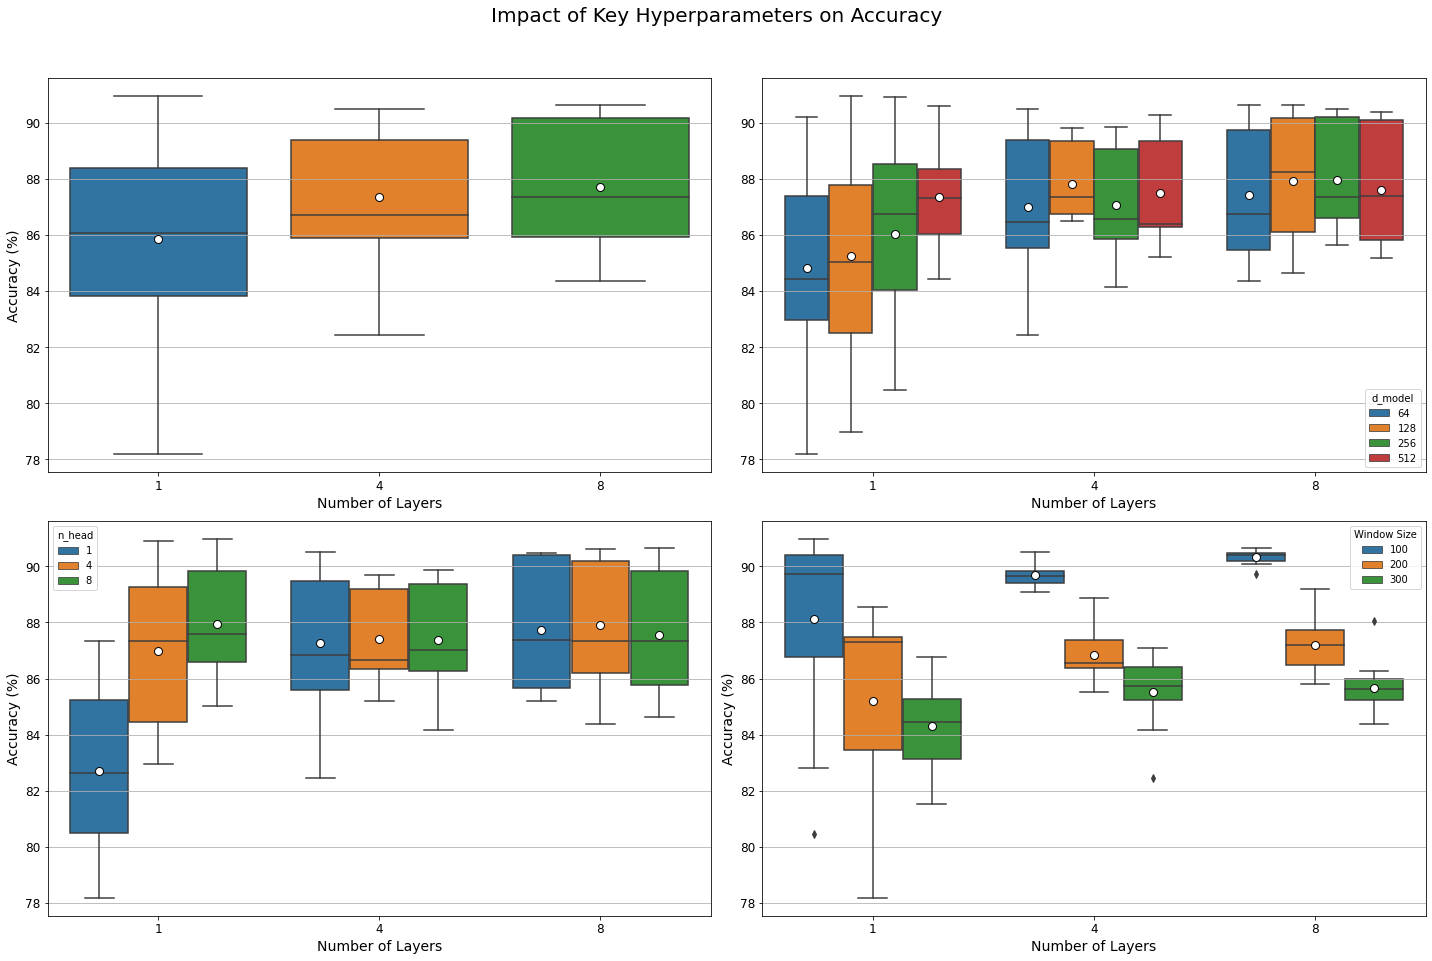


HYPERPARAMETER ANALYSIS SUMMARY
Highest Accuracy Recorded: 90.9716%

Displaying 2 models with accuracy >= 90.77%:
    seq_num  d_model  n_head  num_layer        ACC
15      100      128       8          1  90.971577
21      100      256       4          1  90.915846


In [4]:
#analyze_hyperparameters(directory_path='trained_models/franka_mindlab/m1_cnnBiLSTM_contactDetection/64', plot_show= False, threshold=0.02)
analyze_hyperparameters(directory_path='trained_models/franka_mindlab/m2_cnnBiLSTM_contactDetection/64', plot_show= True, threshold=0.2)
analyze_hyper_transformer(directory_path='trained_models/franka_mindlab/m2_transformer_contactDetection/64', plot_show= True, threshold=0.2)



Output will be saved to: trained_models/franka_mindlab/m2_cnnBiLSTM_contactLocalization/64/analysis_output


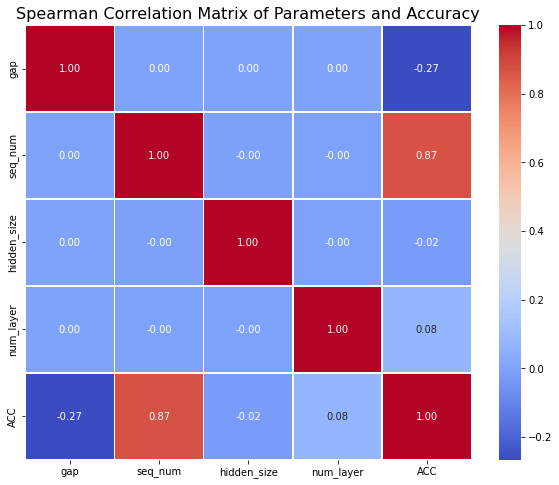

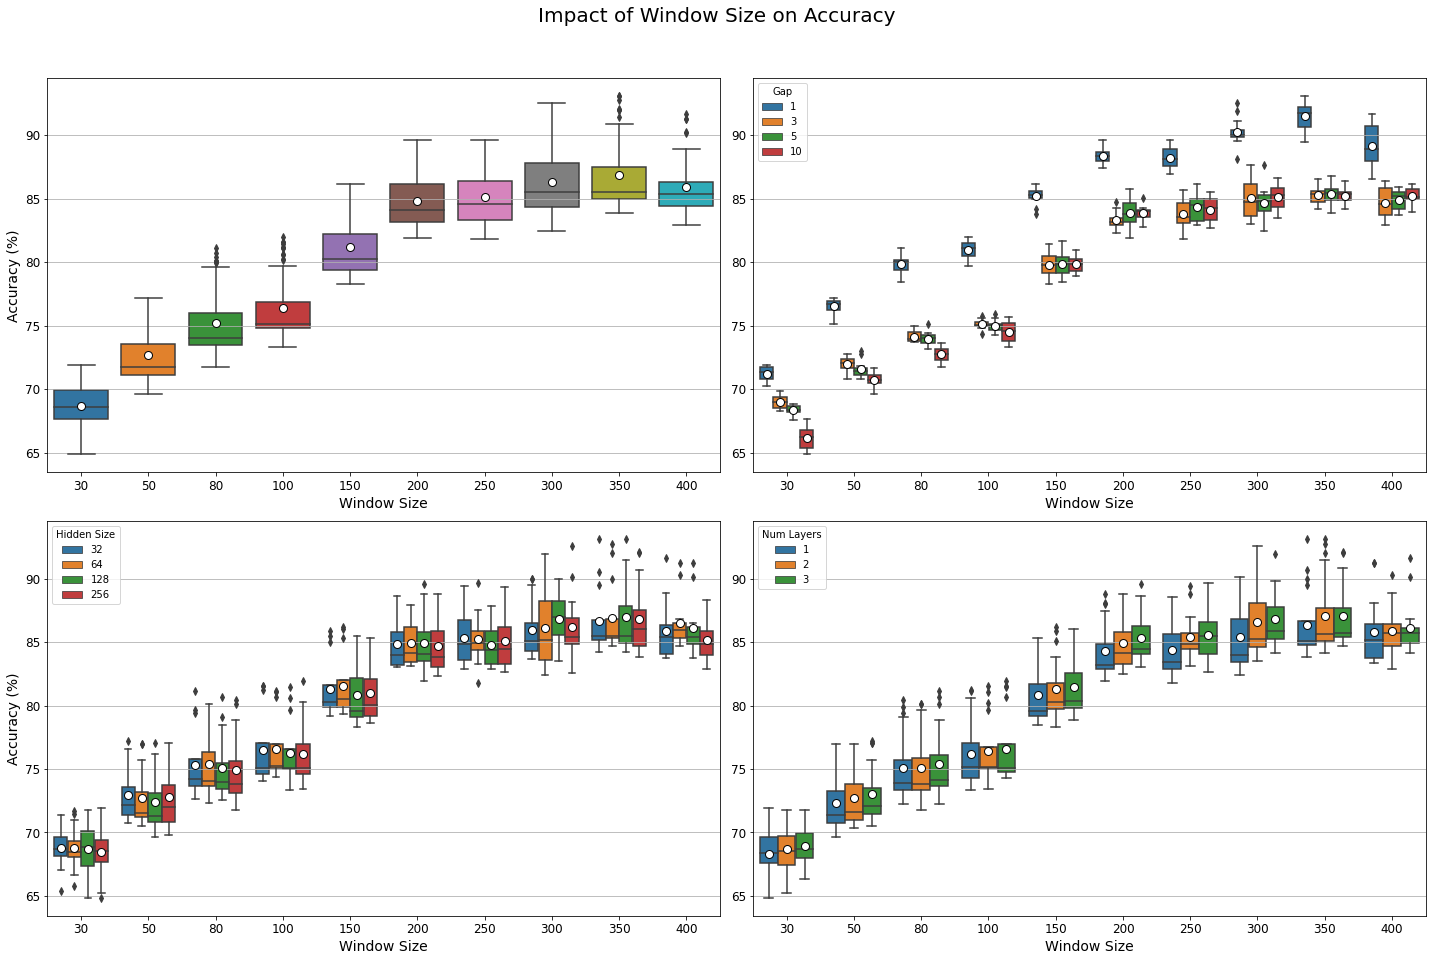

4 models reached accuracy over 92.30%. Highest Accuracy Recorded: 93.1034%
     seq_num  gap  hidden_size  num_layer        ACC  train_size  val_size
94       300    1          256          2  92.548077       20606      1248
97       350    1           32          2  93.103448       20606      1160
100      350    1           64          2  92.758621       20606      1160
102      350    1          128          1  93.103448       20606      1160

Analysis output will be saved to: trained_models/franka_mindlab/m2_transformer_contactLocalization/64/analysis_output


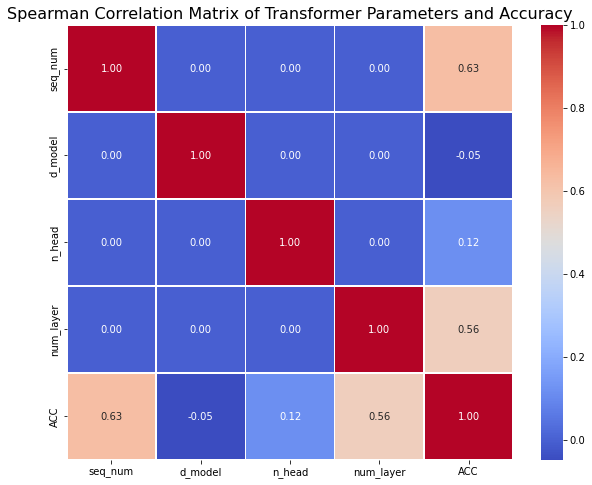

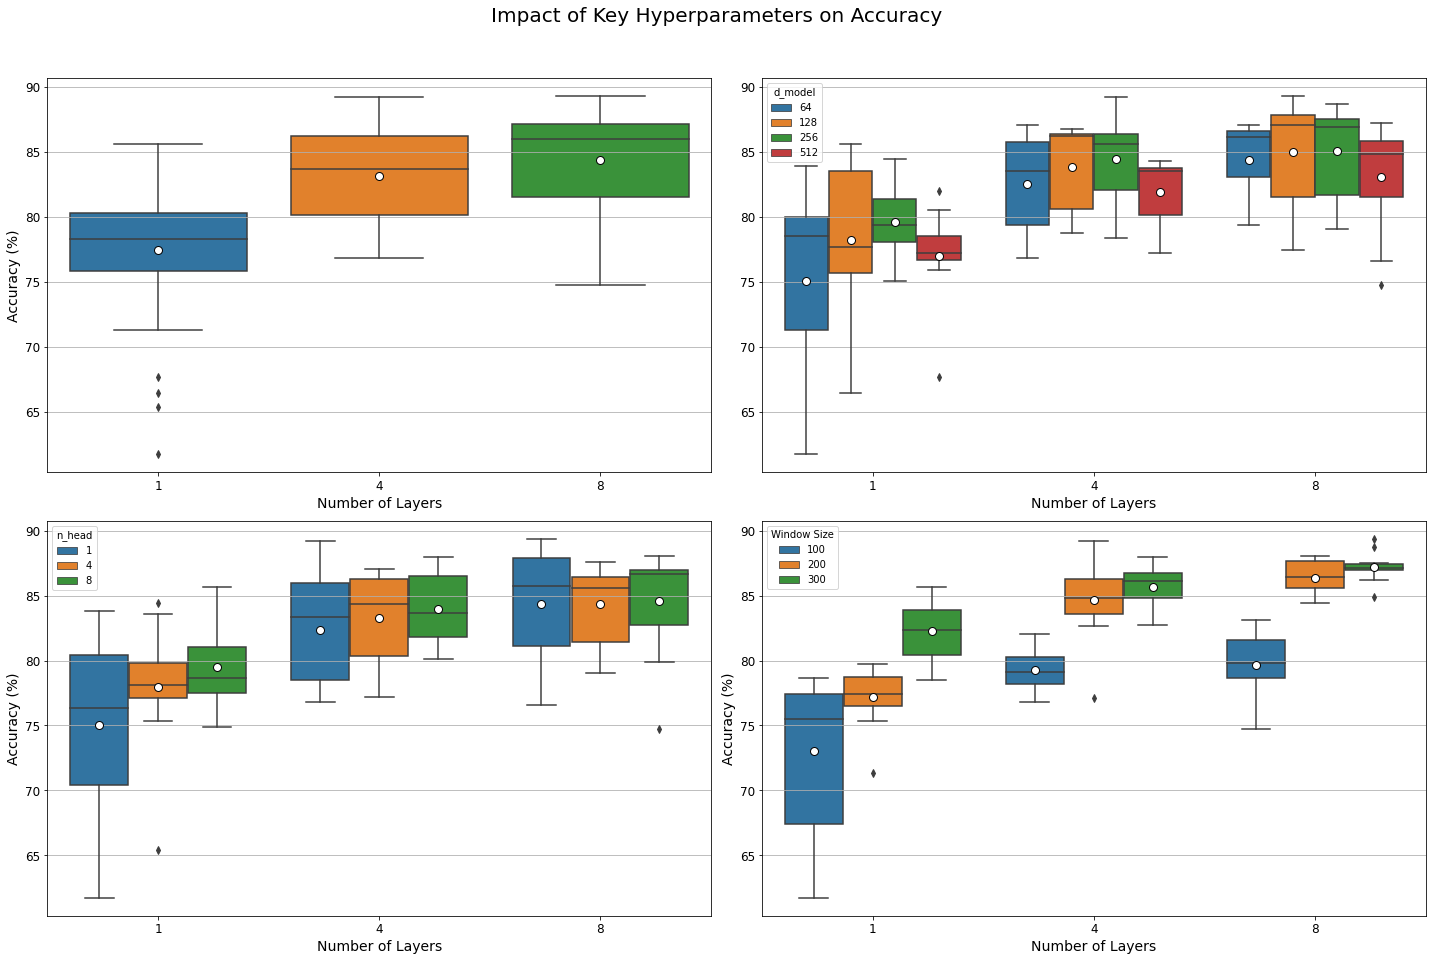


HYPERPARAMETER ANALYSIS SUMMARY
Highest Accuracy Recorded: 89.3429%

Displaying 2 models with accuracy >= 89.14%:
    seq_num  gap  d_model  n_head  num_layer        ACC  train_size  val_size
83      300    1      128       1          8  89.342949       51650      4543
55      200    1      256       1          4  89.236111       53750      4963


In [5]:
#analyze_hyperparameters(directory_path='trained_models/franka_mindlab/m1_cnnBiLSTM_contactLocalization/64', plot_show= False, threshold=0.03)
analyze_hyperparameters(directory_path='trained_models/franka_mindlab/m2_cnnBiLSTM_contactLocalization/64', plot_show= True, threshold=0.8)
analyze_hyper_transformer(directory_path='trained_models/franka_mindlab/m2_transformer_contactLocalization/64', plot_show= True, threshold=0.2)


# Target Robot: UR5


Output will be saved to: trained_models/ur5/m2_cnnBiLSTM_contactDetection/64/analysis_output


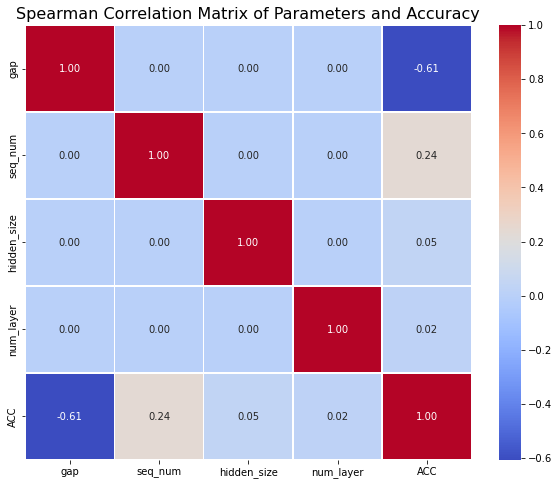

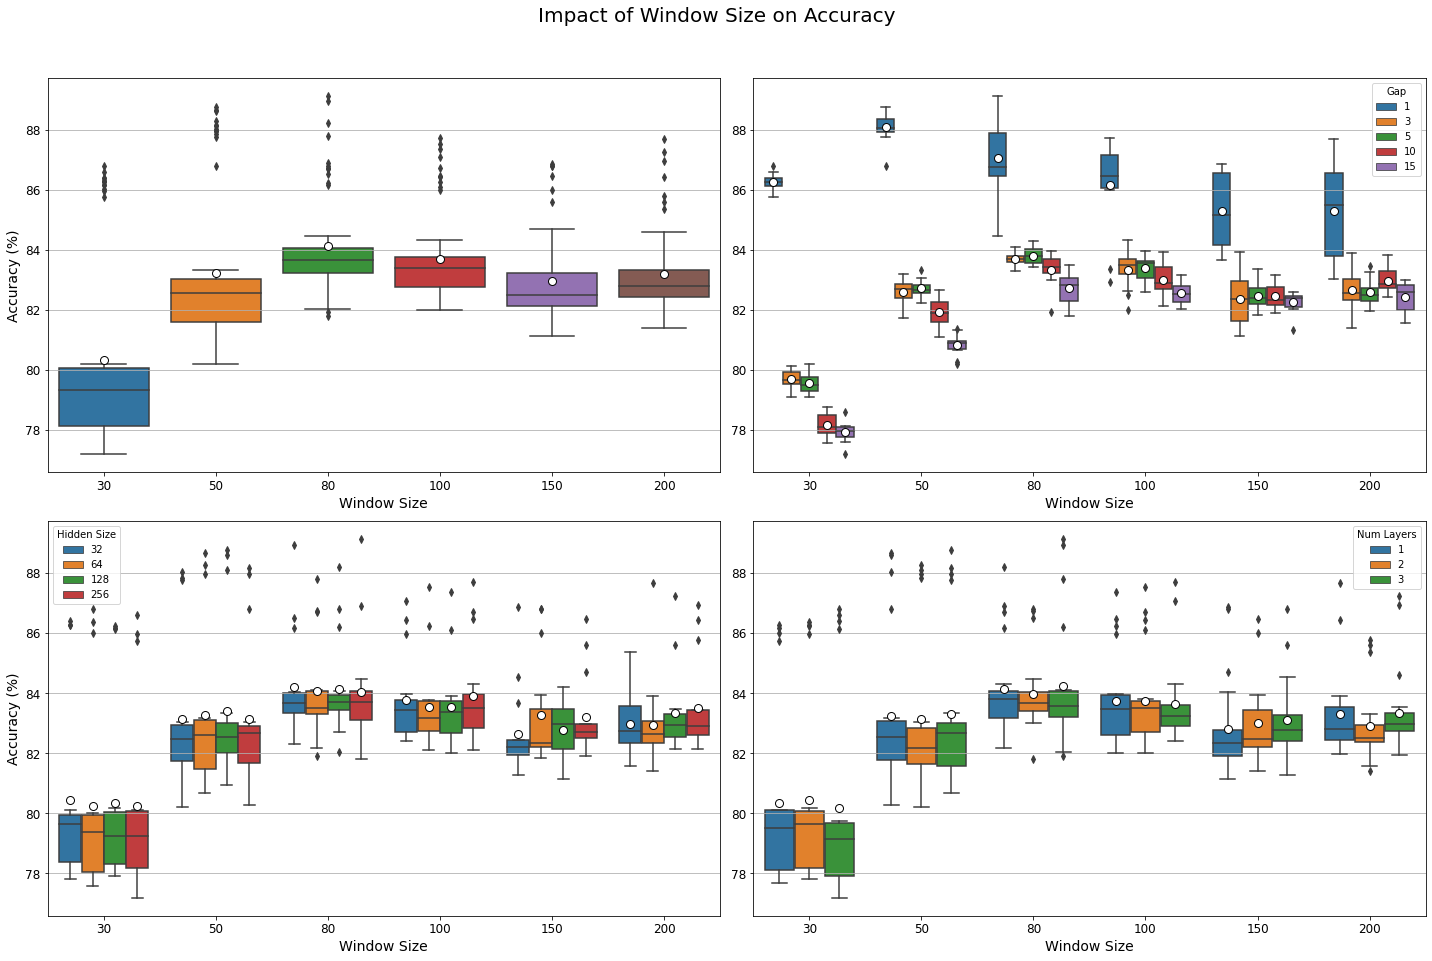

1 models reached accuracy over 89.06%. Highest Accuracy Recorded: 89.1353%
     gap  seq_num  hidden_size  num_layer        ACC  train_size  val_size
323    1       80          256          3  89.135255       64499      6314

Analysis output will be saved to: trained_models/ur5/m2_transformer_contactDetection/64/analysis_output


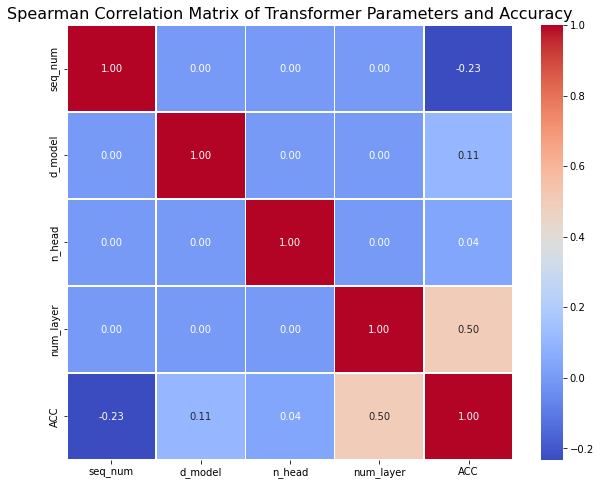

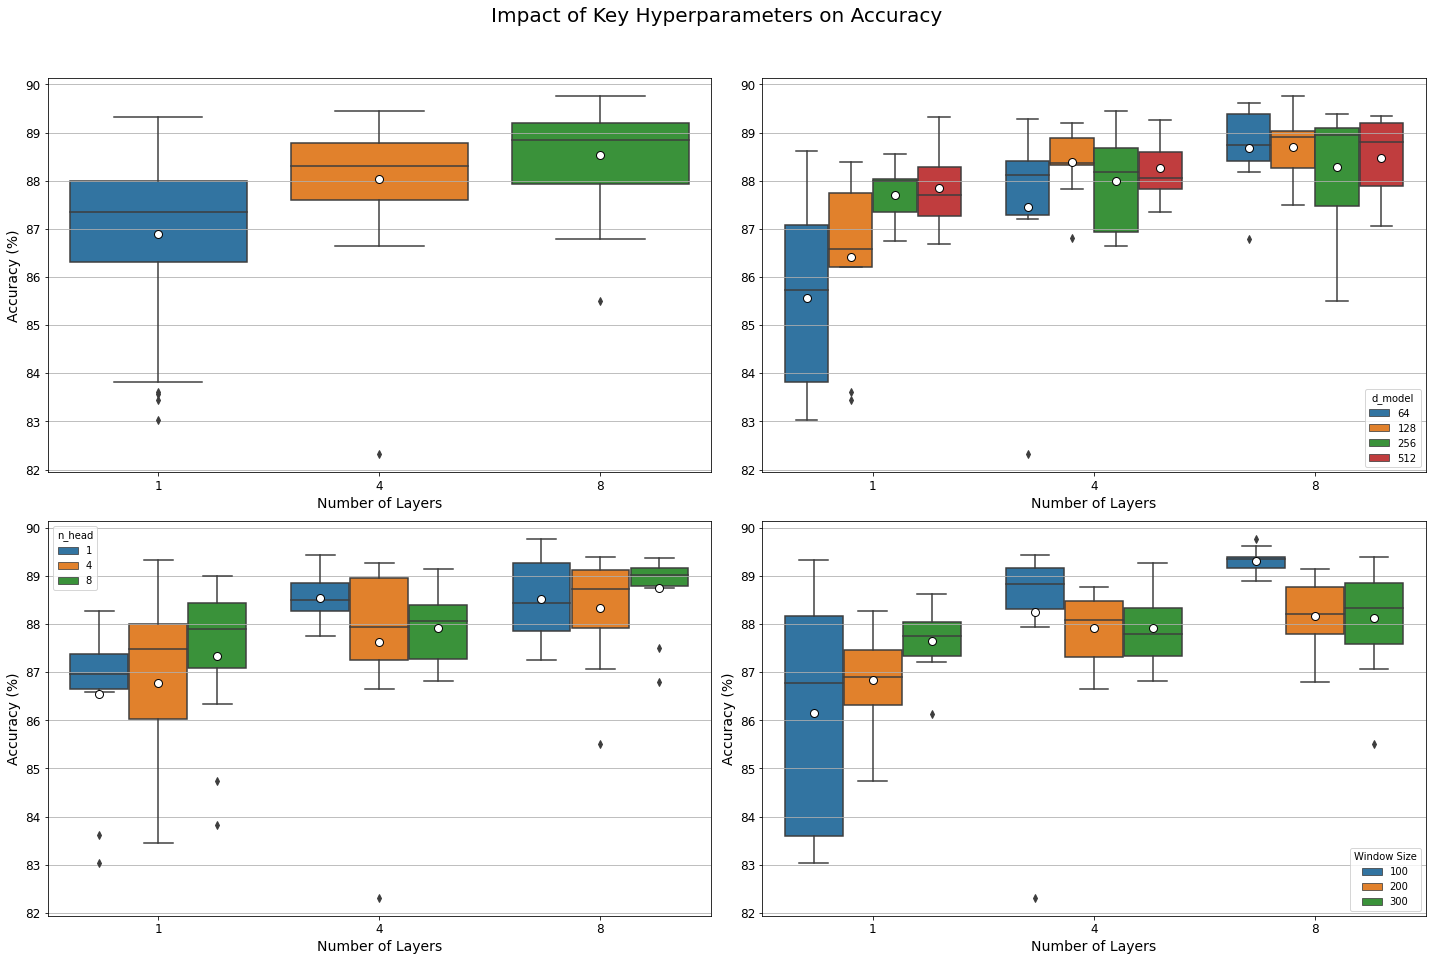


HYPERPARAMETER ANALYSIS SUMMARY
Highest Accuracy Recorded: 89.7629%

Displaying 2 models with accuracy >= 89.56%:
    seq_num  d_model  n_head  num_layer        ACC
11      100      128       1          8  89.762897
2       100       64       1          8  89.618712


In [6]:
#analyze_hyperparameters(directory_path='trained_models/ur5/m1_cnnBiLSTM_contactDetection/64', plot_show= True, threshold=0.2)
analyze_hyperparameters(directory_path='trained_models/ur5/m2_cnnBiLSTM_contactDetection/64/', plot_show= True, threshold=0.08)
analyze_hyper_transformer(directory_path='trained_models/ur5/m2_transformer_contactDetection/64', plot_show= True, threshold=0.2)



Output will be saved to: trained_models/ur5/m2_cnnBiLSTM_contactLocalization/64/analysis_output


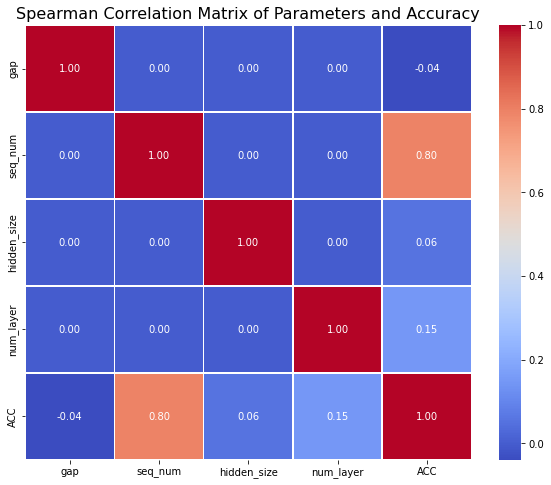

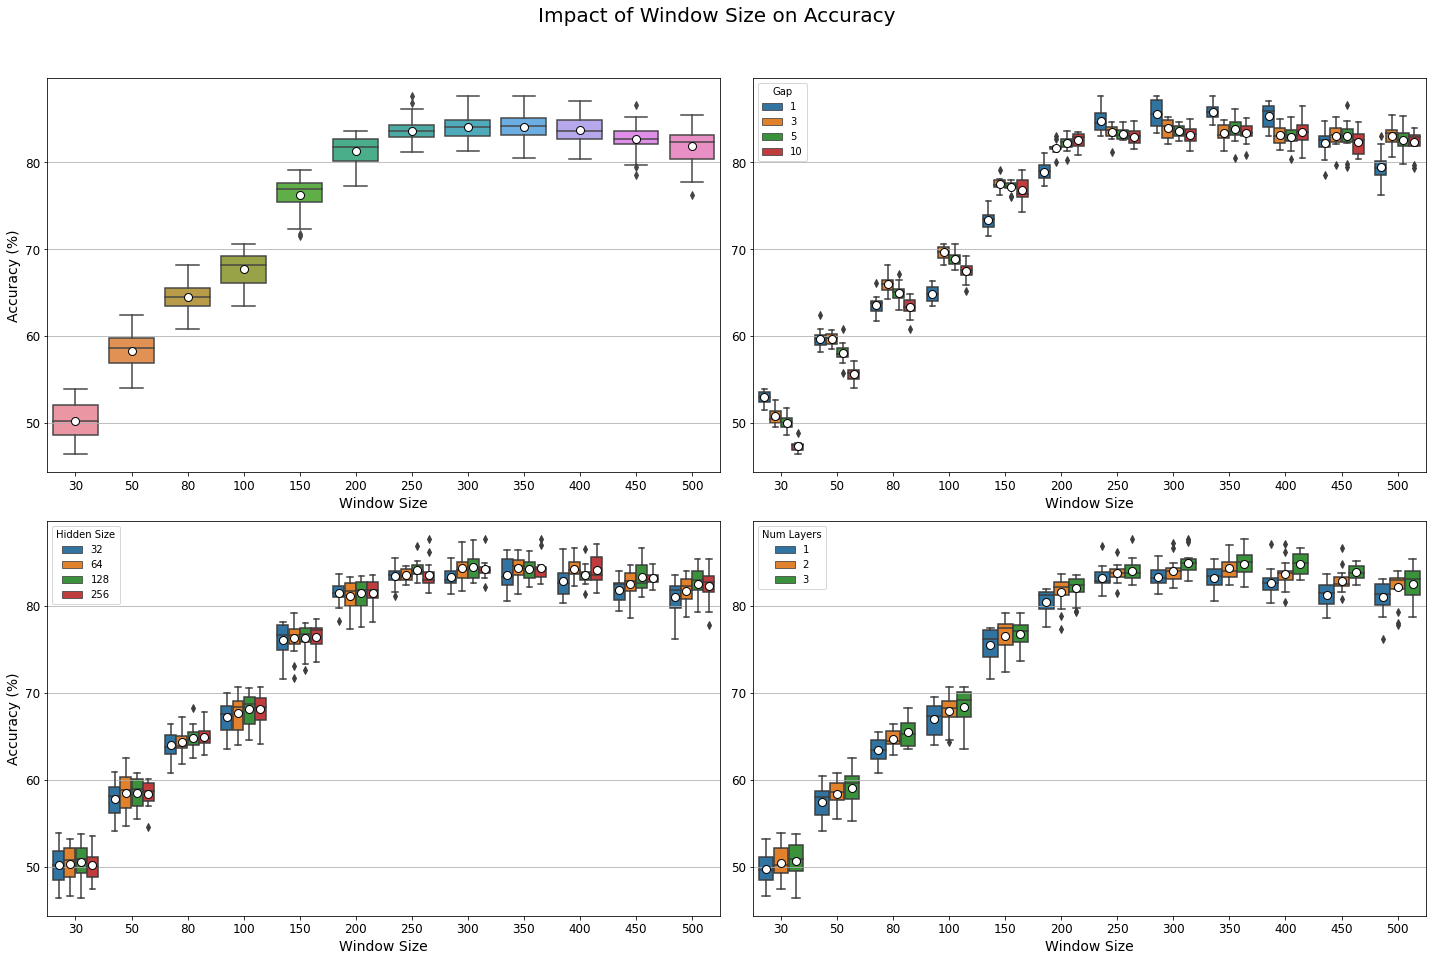

5 models reached accuracy over 87.27%. Highest Accuracy Recorded: 87.6712%
     seq_num  gap  hidden_size  num_layer        ACC  train_size  val_size
515      250    1          256          3  87.643021       18390       874
521      300    1           64          3  87.297634       18390       803
524      300    1          128          3  87.546700       18390       803
527      300    1          256          3  87.671233       18390       803
539      350    1          256          3  87.652646       18390       737

Analysis output will be saved to: trained_models/ur5/m2_transformer_contactLocalization/64/analysis_output


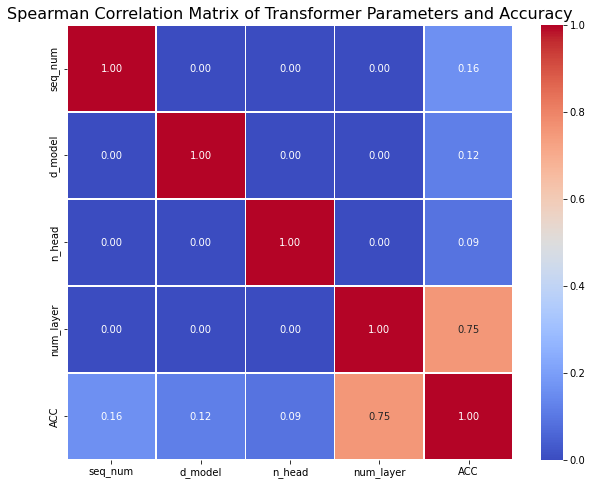

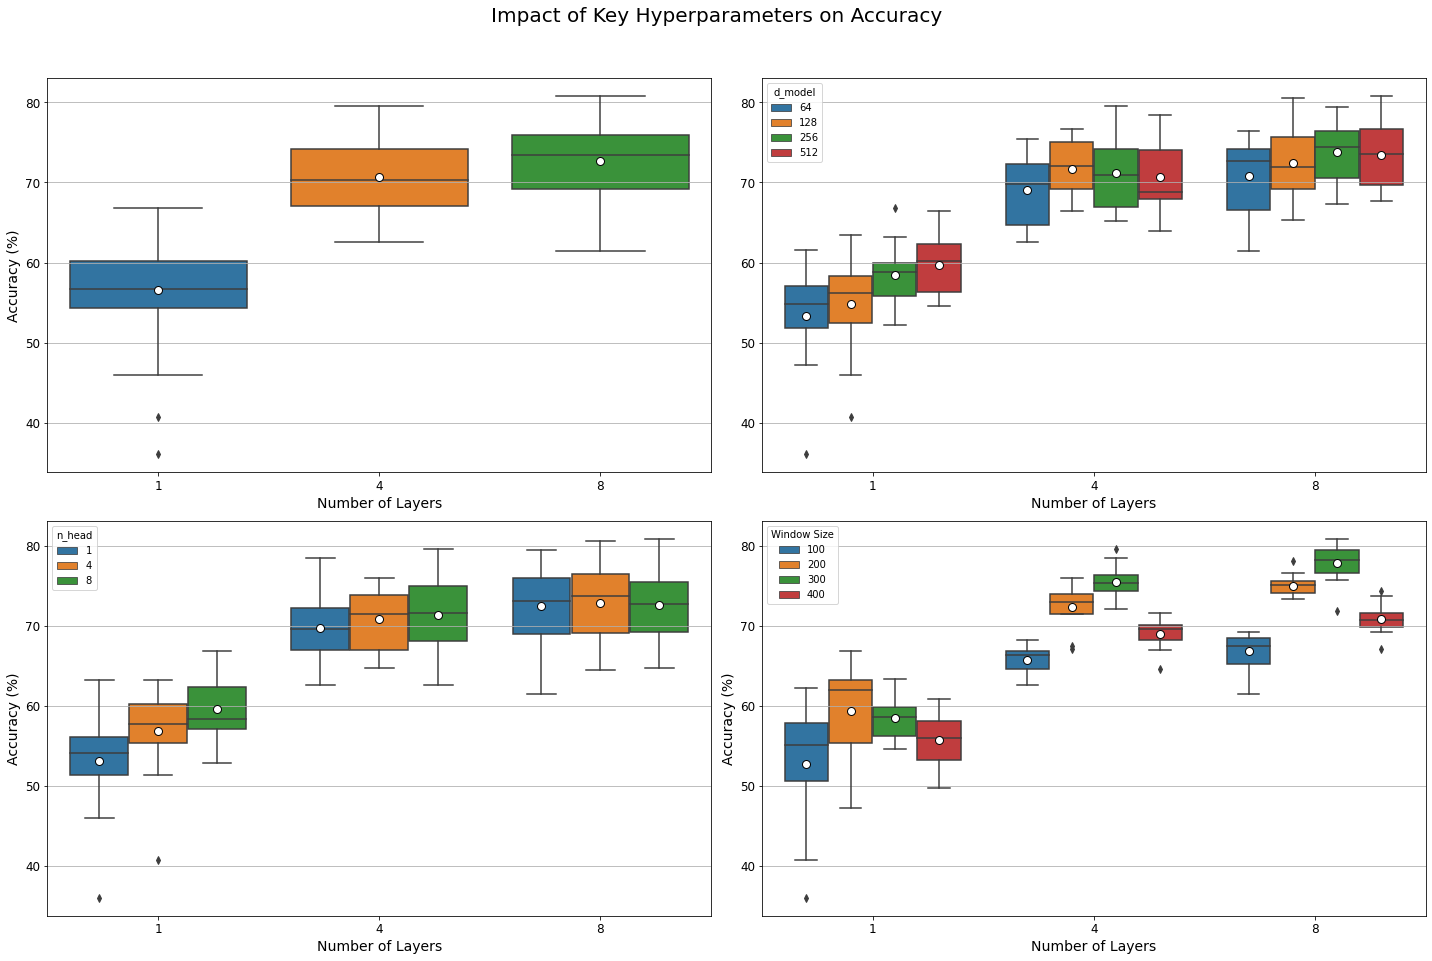


HYPERPARAMETER ANALYSIS SUMMARY
Highest Accuracy Recorded: 80.8219%

Displaying 1 models with accuracy >= 80.62%:
     seq_num  gap  d_model  n_head  num_layer        ACC  train_size  val_size
107      300    1      512       8          8  80.821918       60585      5556


In [7]:
#analyze_hyperparameters(directory_path='trained_models/ur5/m1_cnnBiLSTM_contactLocalization/64', plot_show= True, threshold=0.04)
analyze_hyperparameters(directory_path='trained_models/ur5/m2_cnnBiLSTM_contactLocalization/64', plot_show= True, threshold=0.4)
analyze_hyper_transformer(directory_path='trained_models/ur5/m2_transformer_contactLocalization/64', plot_show= True, threshold=0.2)


# Paper Result

In [1]:
import pandas as pd
import dcor
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from matplotlib.colors import LinearSegmentedColormap

# Define custom two-tone colormap for the heatmap
custom_palette = [ '#67AB9F', '#EA6B66']    
sns.set_palette(custom_palette)
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", custom_palette)

def analyze_hyperparameters(data_path, save_path, plot_show=True, threshold=0.5, gap:int=0, window_size:int=0):
    """
    Analyzes hyperparameter tuning results from a CSV file for either a CNN-BiLSTM
    or a Transformer model. It generates and saves a model-specific box plot,
    a Spearman correlation matrix, and prints a summary of high-performing models.

    Args:
        data_path (str): The full path to the input CSV file.
        save_path (str): The path to the directory where plots will be saved.
        plot_show (bool): If True, displays the plots interactively.
        threshold (float): The accuracy value to subtract from the max accuracy to
                           define high-performing models.
    """
    # --- 1. Load Data and Prepare Paths ---
    try:
        df = pd.read_csv(data_path)
    except FileNotFoundError:
        print(f"Error: The file '{data_path}' was not found.")
        return

    os.makedirs(save_path, exist_ok=True)
    
    data_path_split = data_path.split('/')
    end_idx = len(data_path_split)-1
    mode_name = f'{data_path_split[end_idx-3]}_{data_path_split[end_idx-2]}'
    file_prefix = os.path.join(save_path, f'{mode_name}')
    
    # Define common properties for box plots
    boxplot_props = {
        "showmeans": False,}
    
    '''"meanprops": {
        "marker": "o", "markerfacecolor": "white",
        "markeredgecolor": "black", "markersize": "4"
    }'''

    # --- 2. Model-Specific Preprocessing and Plotting ---
    
    # Use lowercase check for robustness
    if 'cnn' in data_path.lower():
        rename_dict = {
            'seq_num': 'Window Size',
            'gap': 'Gap',
            'hidden_size': 'Hidden Size',
            'num_layer': 'LSTM Layers'
        }
        df.drop(df[df.hidden_size > 256].index, inplace=True) # remove hidden_size>256
        df.rename(columns=rename_dict, inplace=True)
        
        columns_to_correlate = ['Window Size', 'Gap', 'Hidden Size', 'LSTM Layers', 'ACC']
        
        # PLOTTING BLOCK: Create, configure, and save the plot here
        if gap==0:
            plt.figure(figsize=(12, 8))
            num_hues = df['Gap'].nunique()
            custom_palette = [custom_cmap(i/(num_hues-1)) for i in range(num_hues)]

            ax = sns.boxplot(x='Window Size', y='ACC', hue='Gap', data=df,
                            palette=custom_palette, **boxplot_props,
                            boxprops=dict(edgecolor='gray', linewidth=1.0),  # softer edge
                            whiskerprops=dict(color='gray', linewidth=1.0),
                            capprops=dict(color='gray', linewidth=1.0),
                            medianprops=dict(color='black', linewidth=1.0))
            ax.set_xlabel('Window Size (time steps)', fontsize=14)
            ax.set_ylabel('Accuracy (%)', fontsize=14)
            ax.grid(True, axis='y')
            ax.legend(title='Gap')
            
            plot_save_path = f'{file_prefix}_WindowSize_vs_Gap.png'
            plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
            #print(f"Box plot saved to: {plot_save_path}")
        else:
            df.drop(df[df.Gap != gap].index, inplace=True) # remove other gaps
            columns_to_correlate = ['Window Size', 'Hidden Size', 'LSTM Layers', 'ACC']
            if window_size:
                columns_to_correlate = ['Hidden Size', 'LSTM Layers', 'ACC']
                df.drop(df[df['Window Size'] != window_size].index, inplace=True) # remove other gaps
                plt.figure(figsize=(12, 8))

                num_hues = df['LSTM Layers'].nunique()
                custom_palette = [custom_cmap(i/(num_hues-1)) for i in range(num_hues)]
                ax = sns.lineplot(x='Hidden Size', y='ACC', hue='LSTM Layers', data=df,
                                      palette=custom_palette, estimator=None, alpha=0.6)
                
                ax = sns.scatterplot(x='Hidden Size', y='ACC', hue='LSTM Layers', data=df, markers='o',
                                      palette=custom_palette, s=100, edgecolor='gray', legend= False)
                
                ax.set_xlabel('Hidden Size', fontsize=14)
                ax.set_ylabel('Accuracy (%)', fontsize=14)
                ax.grid(True, axis='y')
                ax.legend(title='LSTM Layers')
                plt.xticks(sorted(df['Hidden Size'].unique()))
                plot_save_path = f'{file_prefix}_LSTMLayers_vs_HiddenSize.png'
                plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
            else:
                plt.figure(figsize=(12, 8))
                num_hues = df['Hidden Size'].nunique()
                custom_palette = [custom_cmap(i/(num_hues-1)) for i in range(num_hues)]

                ax = sns.boxplot(x='Window Size', y='ACC', hue='Hidden Size', data=df,
                                palette=custom_palette, **boxplot_props,
                                boxprops=dict(edgecolor='gray', linewidth=1.0),  # softer edge
                                whiskerprops=dict(color='gray', linewidth=1.0),
                                capprops=dict(color='gray', linewidth=1.0),
                                medianprops=dict(color='black', linewidth=1.0))
                ax.set_xlabel('Window Size (time steps)', fontsize=14)
                ax.set_ylabel('Accuracy (%)', fontsize=14)
                ax.grid(True, axis='y')
                ax.legend(title='Hidden Size')
                
                plot_save_path = f'{file_prefix}_WindowSize_vs_HiddenSize.png'
                plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')

                plt.figure(figsize=(12, 8))
                num_hues = df['LSTM Layers'].nunique()
                custom_palette = [custom_cmap(i/(num_hues-1)) for i in range(num_hues)]

                ax = sns.boxplot(x='Window Size', y='ACC', hue='LSTM Layers', data=df,
                                palette=custom_palette, **boxplot_props,
                                boxprops=dict(edgecolor='gray', linewidth=1.0),  # softer edge
                                whiskerprops=dict(color='gray', linewidth=1.0),
                                capprops=dict(color='gray', linewidth=1.0),
                                medianprops=dict(color='black', linewidth=1.0))
                ax.set_xlabel('Window Size (time steps)', fontsize=14)
                ax.set_ylabel('Accuracy (%)', fontsize=14)
                ax.grid(True, axis='y')
                ax.legend(title='LSTM Layers')
                
                plot_save_path = f'{file_prefix}_WindowSize_vs_LSTMLayers.png'
                plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')

            '''dist_corr_matrix = pd.DataFrame(index=columns_to_correlate, columns=columns_to_correlate)
            for col1 in columns_to_correlate:
                for col2 in columns_to_correlate:
                    x=df[col1].astype(float).values
                    y=df[col2].astype(float).values
                    dist_corr_matrix.loc[col1, col2] = dcor.distance_correlation(x, y)
            
            print(dist_corr_matrix)'''

    elif 'transformer' in data_path.lower():
        #print(f"\n--- Analyzing Transformer Model: {file_prefix} ---")
        # Drop columns and filter rows first
        df.drop(columns=['dropout', 'weight_decay', 'learning_rate'], inplace=True, errors='ignore')
        df.drop(df[df.d_model > 512].index, inplace=True) # remove d_models=1024
        
        rename_dict = {
            'seq_num': 'Window Size',
            'n_head': 'Attention Heads',
            'num_layer': 'Encoder Layers',
            'd_model': 'd_model'
        }
        df.rename(columns=rename_dict, inplace=True)
        
        columns_to_correlate = ['Encoder Layers', 'Window Size', 'Attention Heads', 'd_model',  'ACC']

        # PLOTTING BLOCK: Create, configure, and save the plot here
        plt.figure(figsize=(12, 8))
        num_hues = df['Window Size'].nunique()
        custom_palette = [custom_cmap(i/(num_hues-1)) for i in range(num_hues)]

        ax = sns.boxplot(x='Encoder Layers', y='ACC', hue='Window Size', data=df,
                         palette=custom_palette, **boxplot_props,
                         boxprops=dict(edgecolor='gray', linewidth=1.0),  # softer edge
                         whiskerprops=dict(color='gray', linewidth=1.0),
                         capprops=dict(color='gray', linewidth=1.0),
                         medianprops=dict(color='black', linewidth=1.0))
        
        ax.set_xlabel('Encoder Layers', fontsize=14)
        ax.set_ylabel('Accuracy (%)', fontsize=14)
        ax.grid(True, axis='y')
        ax.legend(title='Window Size')
        
        plot_save_path = f'{file_prefix}_EncoderLayers_vs_WindowSize.png'
        plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
        # print(f"Box plot saved to: {plot_save_path}")

    else:
        print(f"Error: Could not determine model type from path '{data_path}'. Expected 'cnn' or 'transformer'.")
        return

    if plot_show:
        plt.show()
    else:
        plt.close()

    # --- 3. Correlation Analysis (Common for all models) ---
    corr_matrix = df[columns_to_correlate].corr(method='spearman')
    print(corr_matrix)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap= custom_cmap, #'coolwarm',
        fmt=".2f",
        linewidths=.5
    )
    plt.title('Spearman Correlation Matrix of Parameters and Accuracy', fontsize=16)
    
    corr_save_path = f'{file_prefix}_correlation_matrix.png'
    plt.savefig(corr_save_path, dpi=300, bbox_inches='tight')

    if plot_show:
        plt.show()
    else:
        plt.close()

    # --- 4. Summary Statistics (Common for all models) ---
    if not df.empty and 'ACC' in df.columns:
        max_acc = df['ACC'].max()
        high_accuracy_threshold = max_acc - threshold
        high_performers_df = df.loc[df['ACC'] >= high_accuracy_threshold].sort_values(by='ACC', ascending=False)
        
        print(f"Highest Accuracy Recorded: {max_acc:.4f}%")
        #print(f"\nDisplaying {len(high_performers_df)} models with accuracy >= {high_accuracy_threshold:.2f}%:")
        # Displaying with original column names for clarity if they exist
    else:
        print("\nCould not generate summary statistics. DataFrame is empty or missing 'ACC' column.")

🔍 Searching for folders containing '64' inside 'trained_models/'...
✅ Found 18 result file(s) to analyze.
trained_models/franka_main/m1_cnnBiLSTM_contactLocalization/64/hyperparameter_results_localization.csv


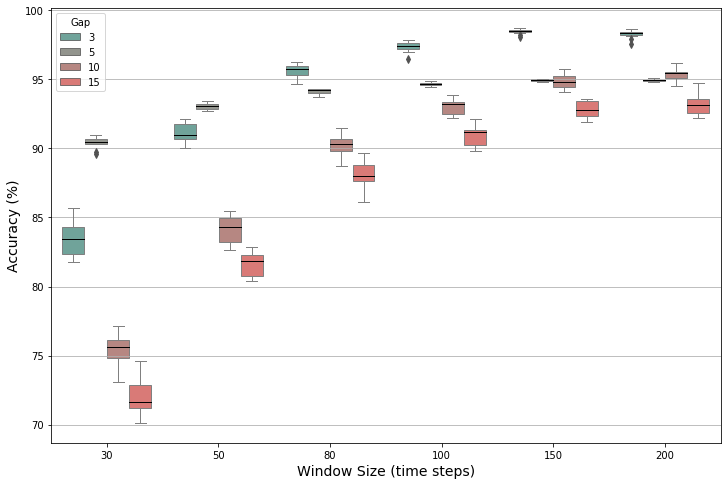

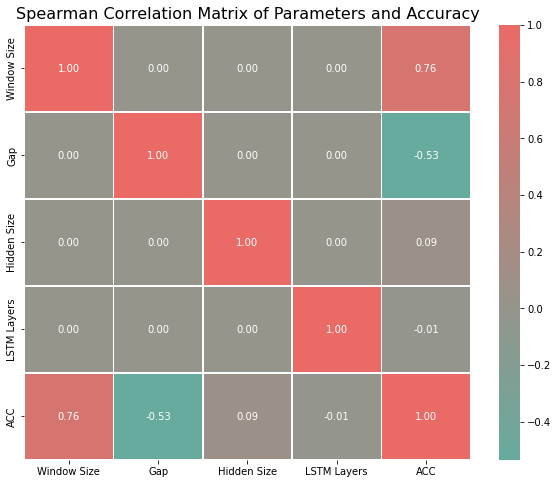

Highest Accuracy Recorded: 98.7460%
trained_models/franka_main/m2_cnnBiLSTM_contactDetection/64/hyperparameter_results.csv


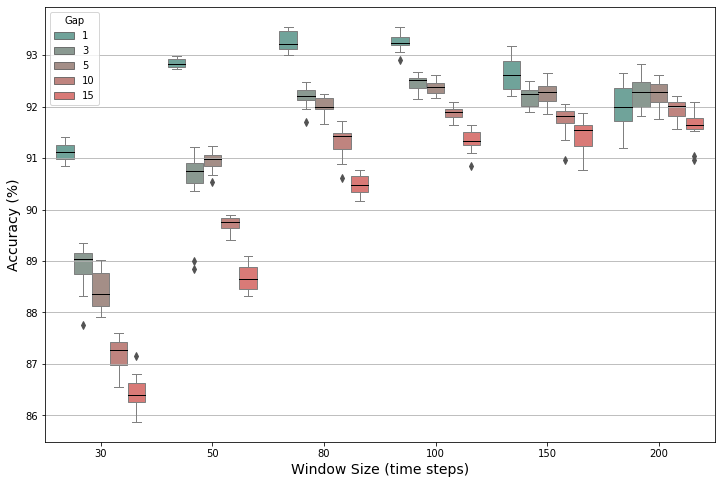

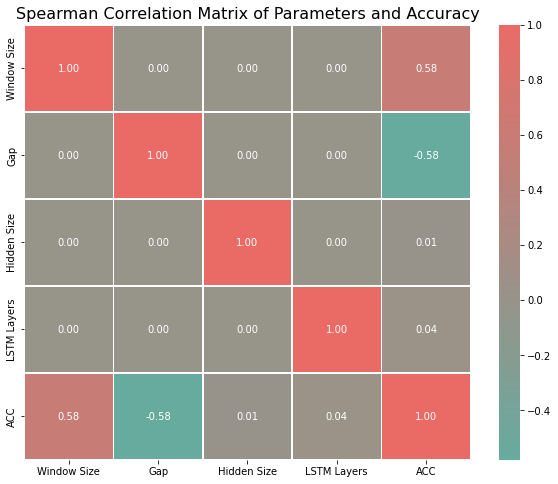

Highest Accuracy Recorded: 93.5544%
trained_models/franka_main/m1_cnnBiLSTM_contactDetection/64/hyperparameter_results.csv


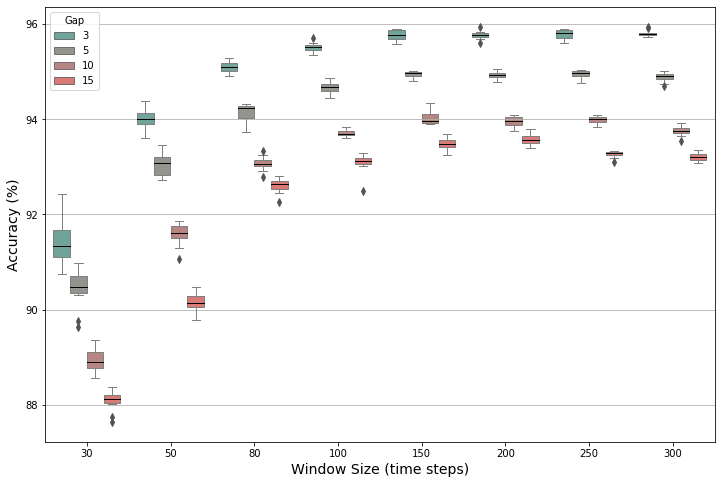

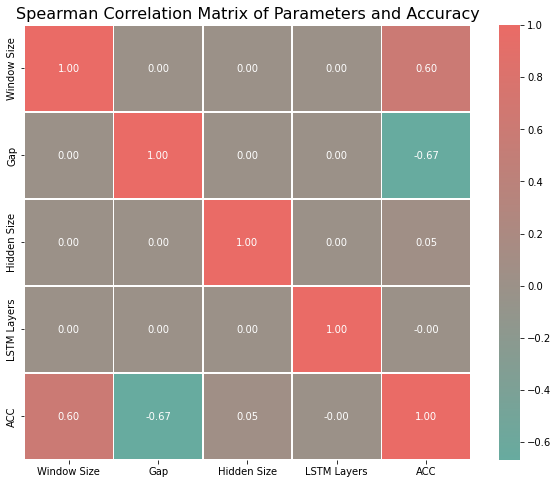

Highest Accuracy Recorded: 95.9478%
trained_models/franka_main/m2_transformer_contactLocalization/64/hyperparameter_results_localization.csv


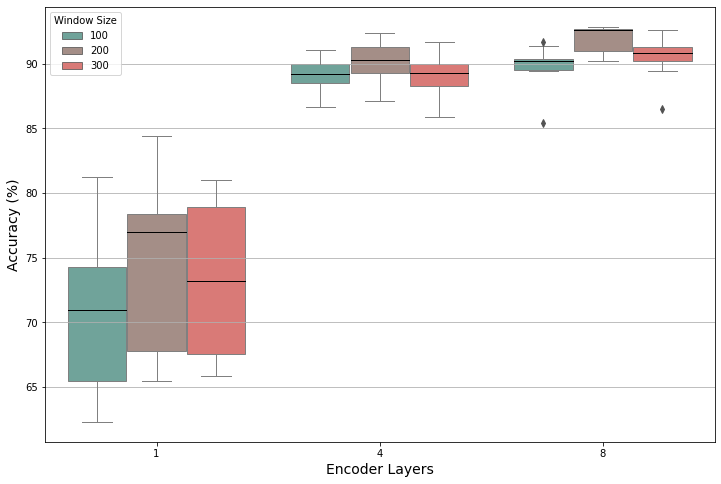

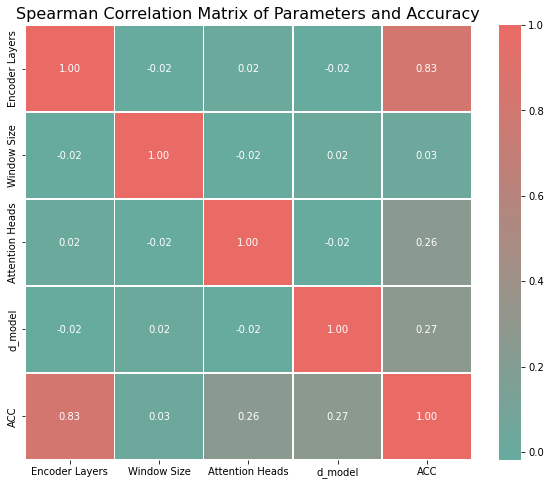

Highest Accuracy Recorded: 92.8648%
trained_models/franka_main/m2_transformer_contactDetection/64/hyperparameter_results_expanded.csv


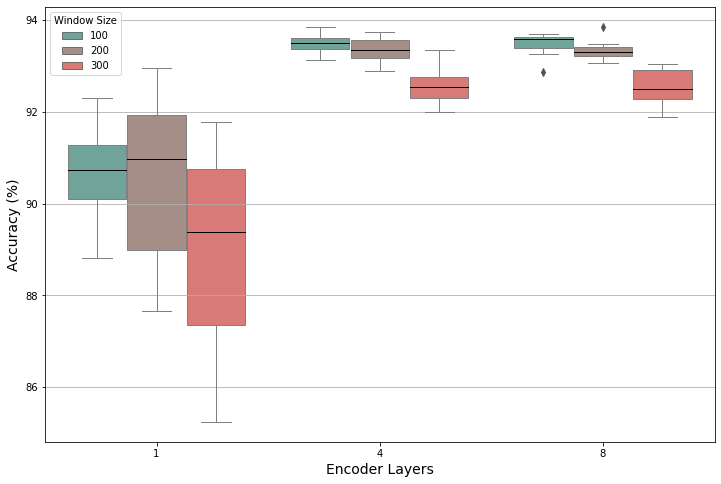

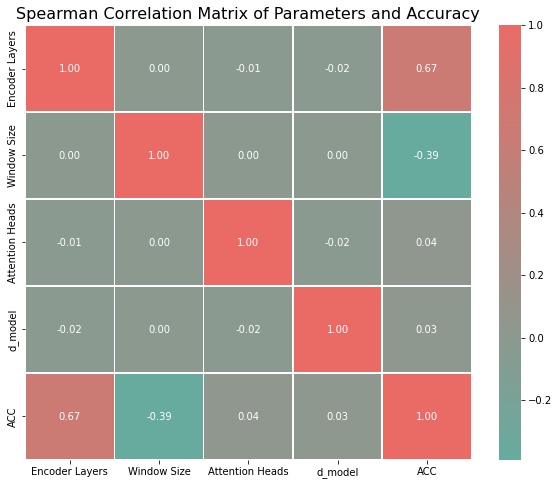

Highest Accuracy Recorded: 93.8560%
trained_models/franka_main/m2_cnnBiLSTM_contactLocalization/64/hyperparameter_results_localization.csv


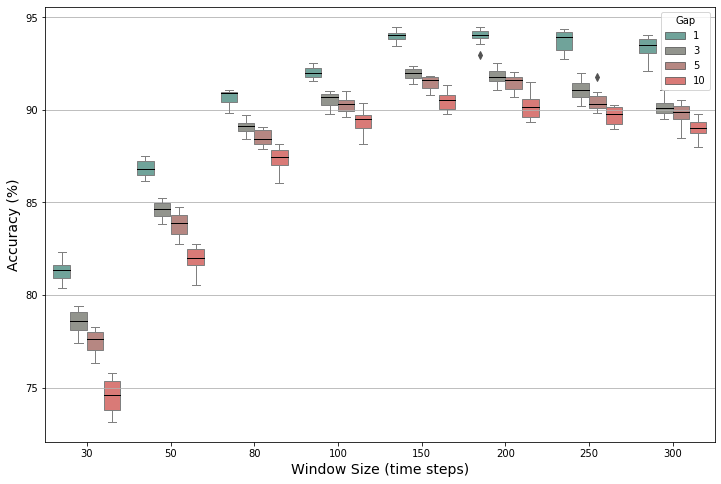

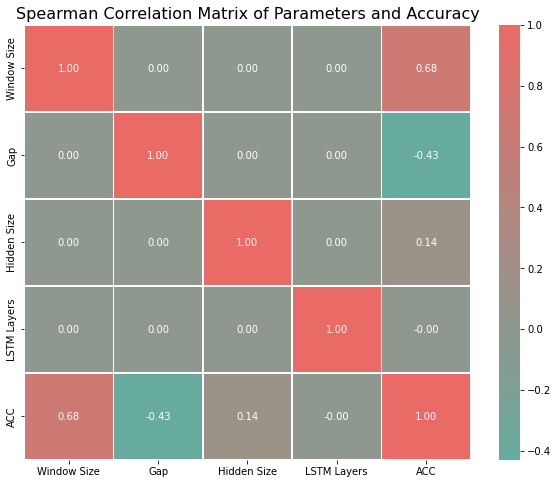

Highest Accuracy Recorded: 94.4918%
trained_models/franka_mindlab/m1_cnnBiLSTM_contactLocalization/64/hyperparameter_results_localization.csv


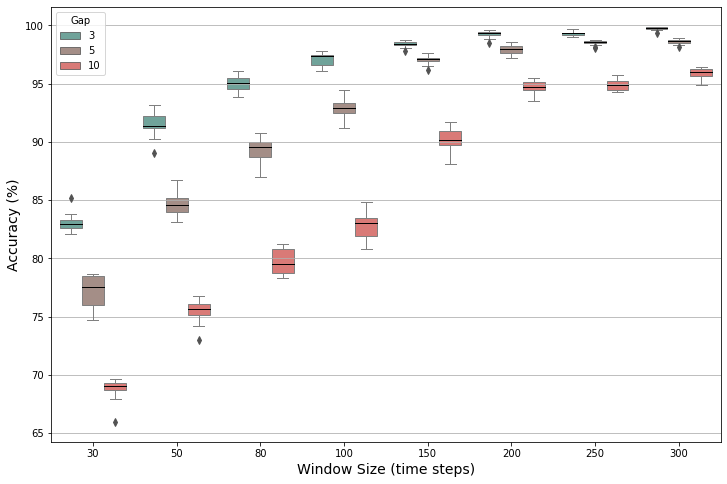

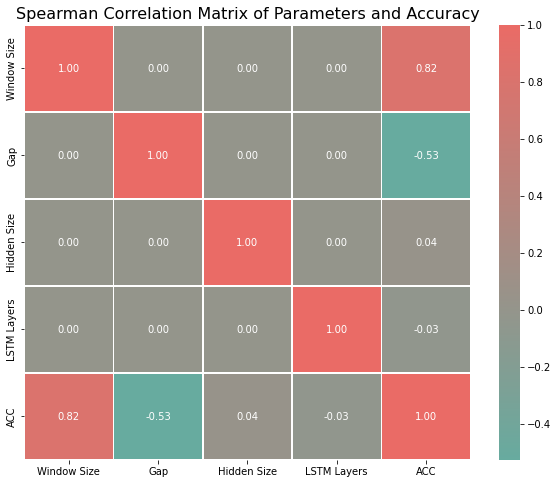

Highest Accuracy Recorded: 99.8796%
trained_models/franka_mindlab/m2_cnnBiLSTM_contactDetection/64/hyperparameter_results.csv


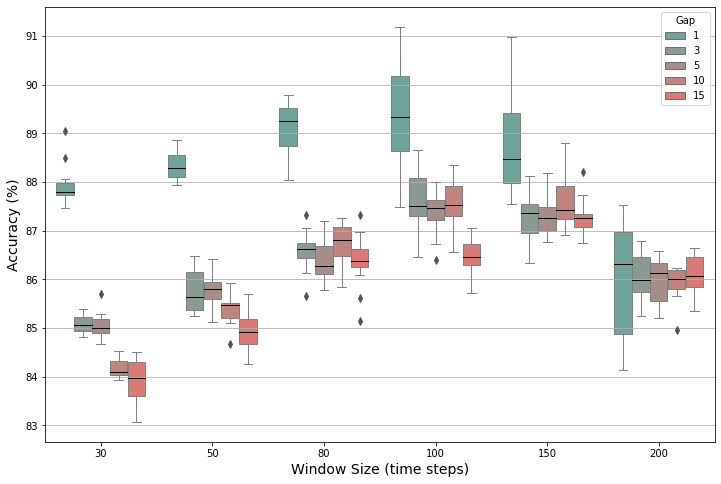

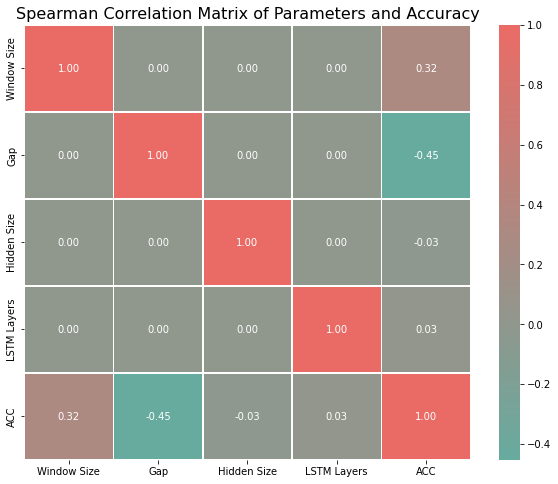

Highest Accuracy Recorded: 91.1945%
trained_models/franka_mindlab/m1_cnnBiLSTM_contactDetection/64/hyperparameter_results.csv


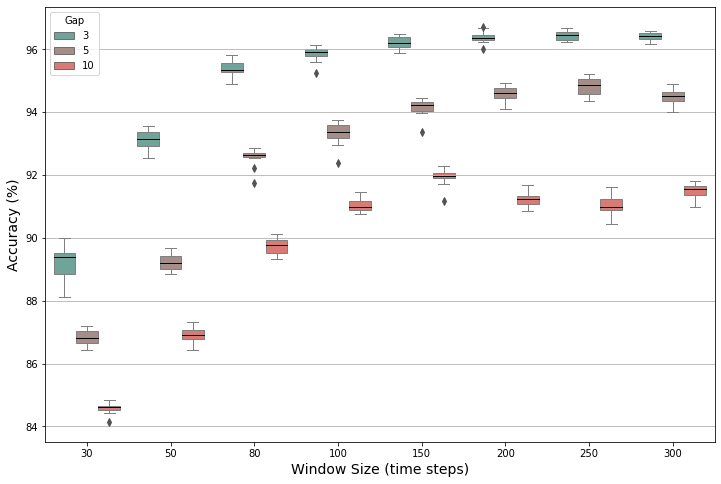

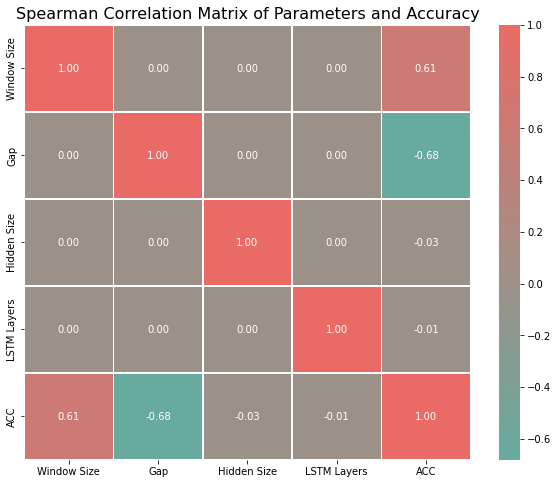

Highest Accuracy Recorded: 96.7215%
trained_models/franka_mindlab/m2_transformer_contactLocalization/64/hyperparameter_results_localization.csv


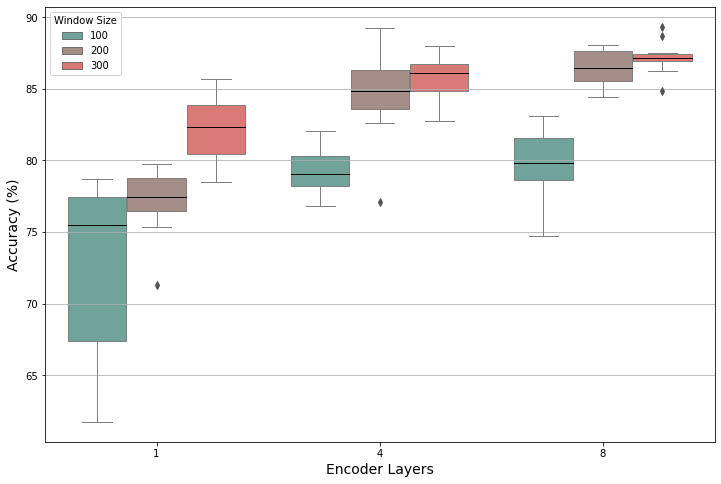

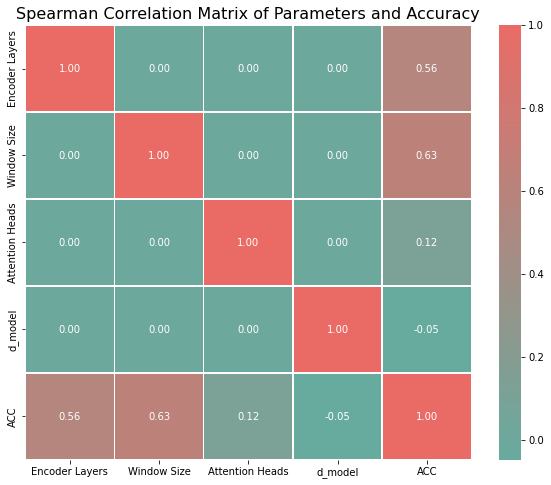

Highest Accuracy Recorded: 89.3429%
trained_models/franka_mindlab/m2_transformer_contactDetection/64/hyperparameter_results_expanded.csv


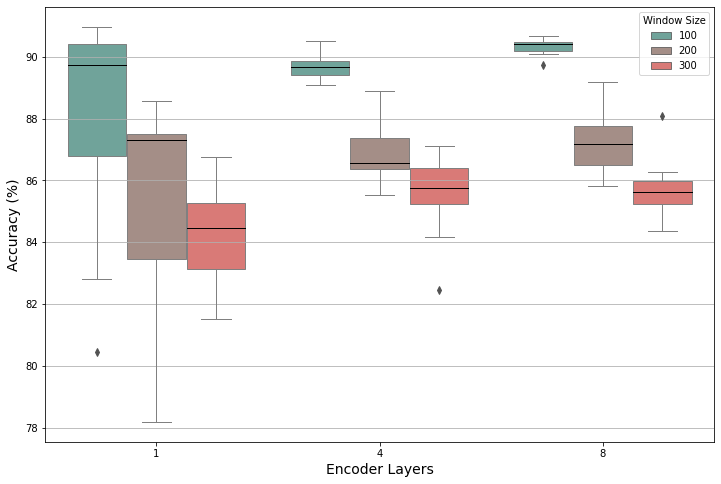

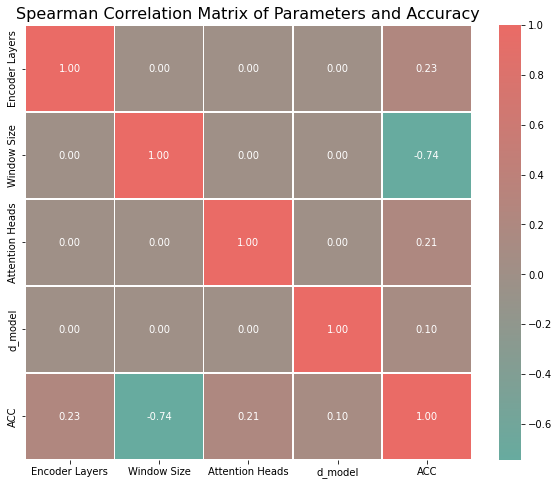

Highest Accuracy Recorded: 90.9716%
trained_models/franka_mindlab/m2_cnnBiLSTM_contactLocalization/64/hyperparameter_results_localization.csv


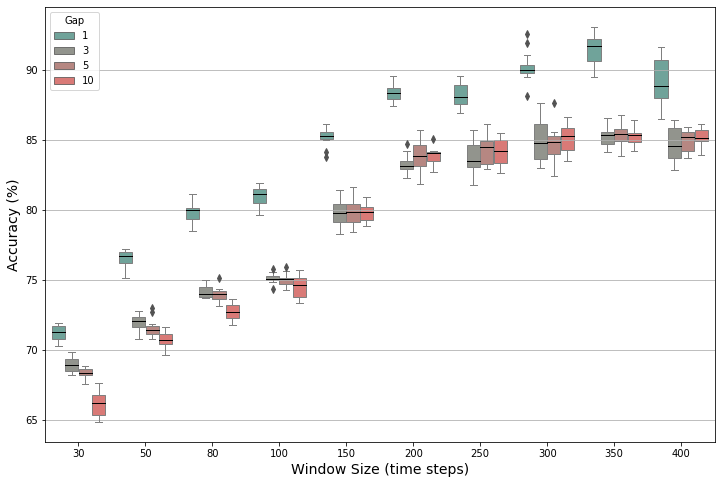

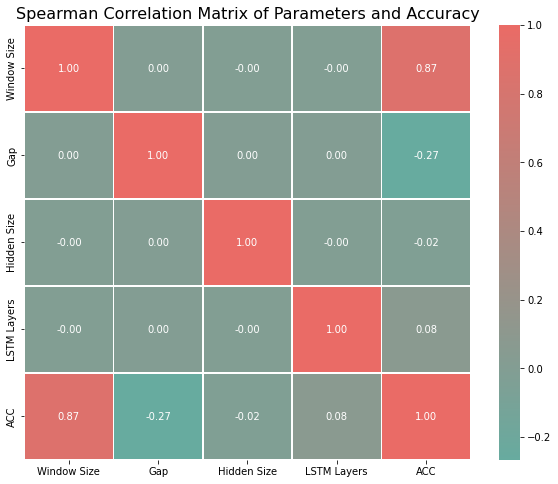

Highest Accuracy Recorded: 93.1034%
trained_models/ur5/m1_cnnBiLSTM_contactLocalization/64/hyperparameter_results_localization.csv


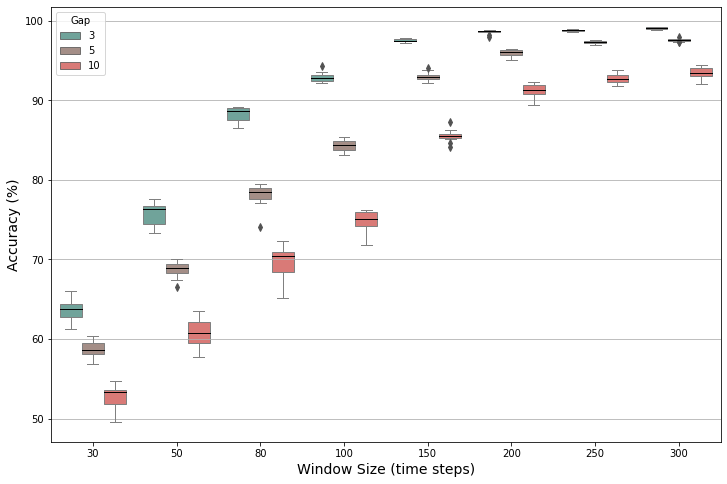

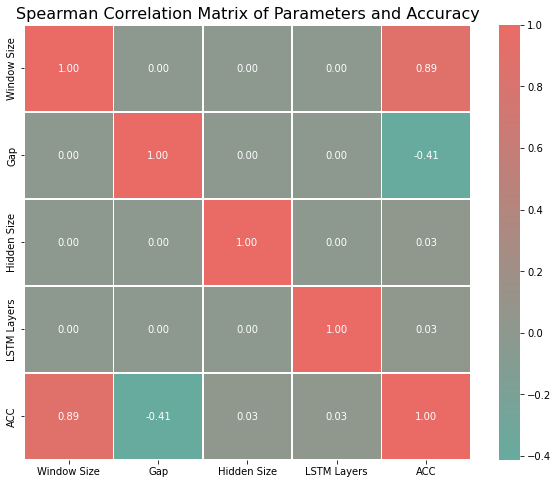

Highest Accuracy Recorded: 99.2718%
trained_models/ur5/m2_cnnBiLSTM_contactDetection/64/hyperparameter_results.csv


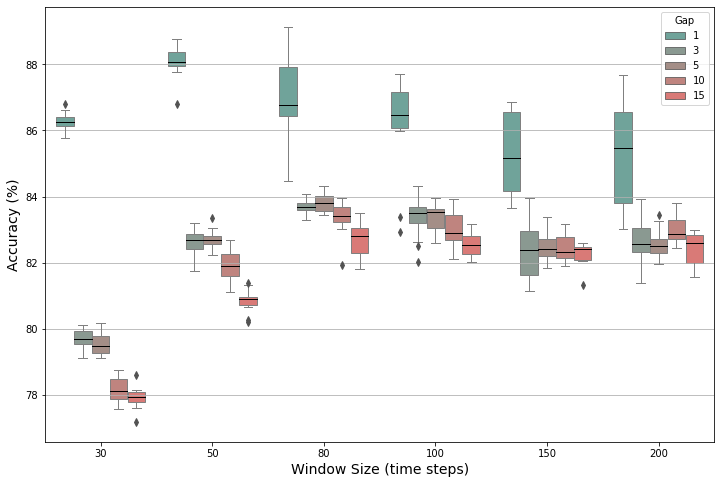

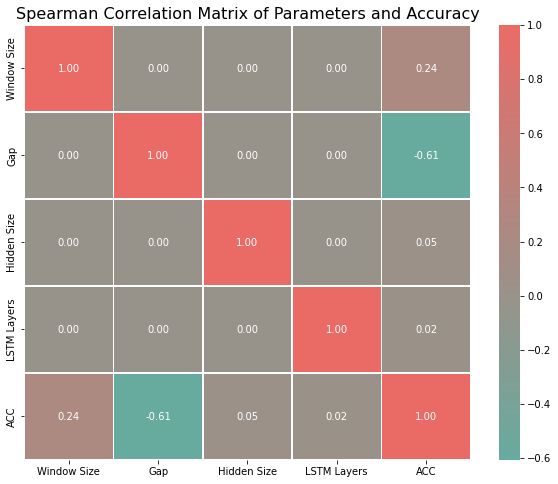

Highest Accuracy Recorded: 89.1353%
trained_models/ur5/m1_cnnBiLSTM_contactDetection/64/hyperparameter_results.csv


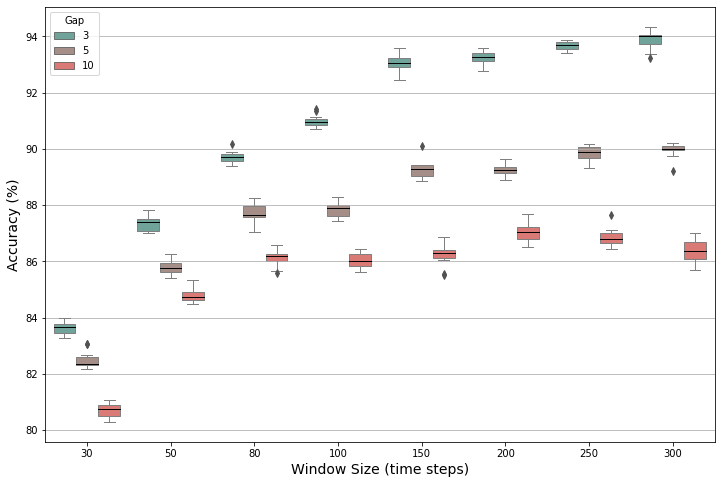

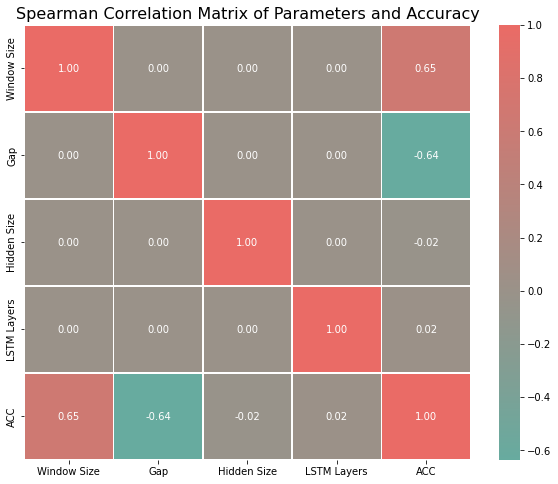

Highest Accuracy Recorded: 94.3411%
trained_models/ur5/m2_transformer_contactLocalization/64/hyperparameter_results_localization.csv


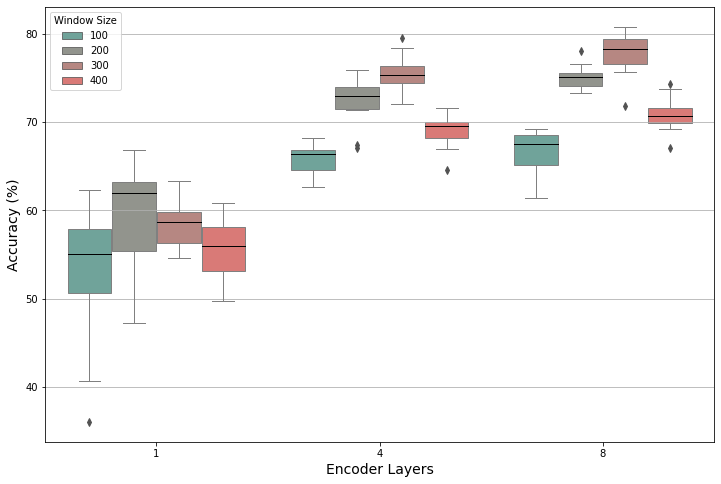

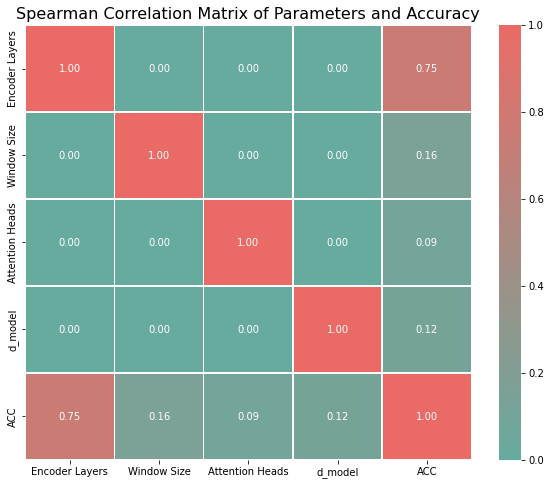

Highest Accuracy Recorded: 80.8219%
trained_models/ur5/m2_transformer_contactDetection/64/hyperparameter_results_expanded.csv


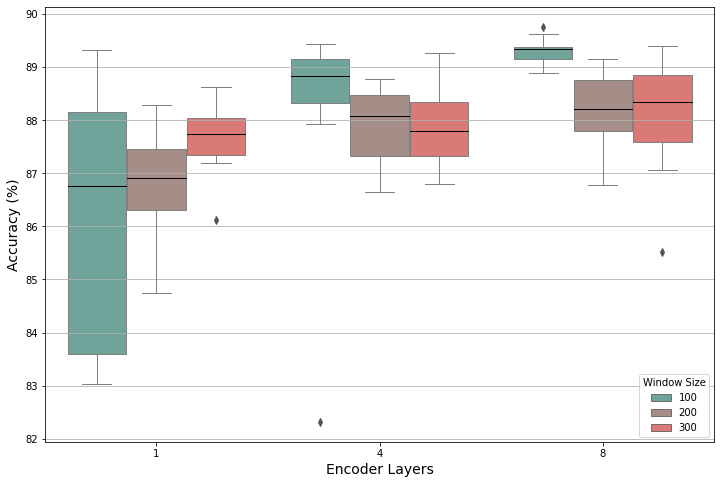

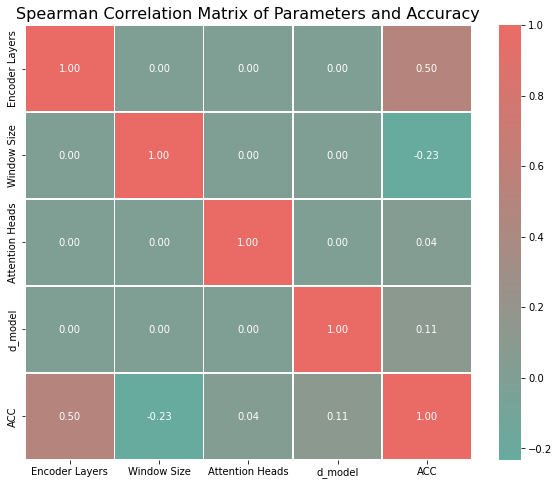

Highest Accuracy Recorded: 89.7629%
trained_models/ur5/m2_cnnBiLSTM_contactLocalization/64/hyperparameter_results_localization.csv


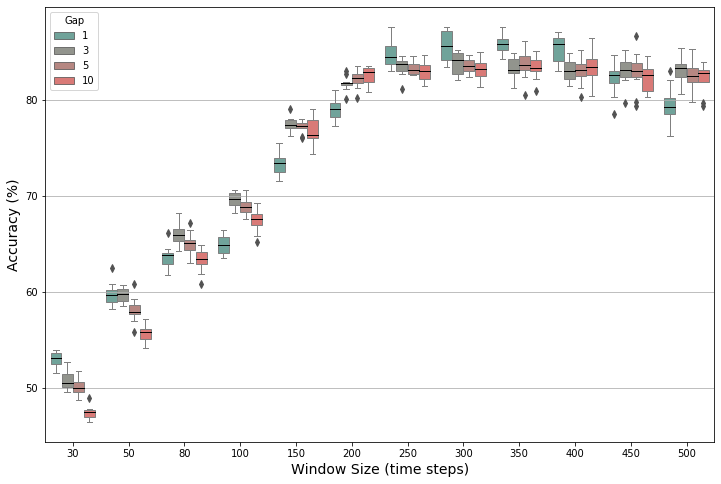

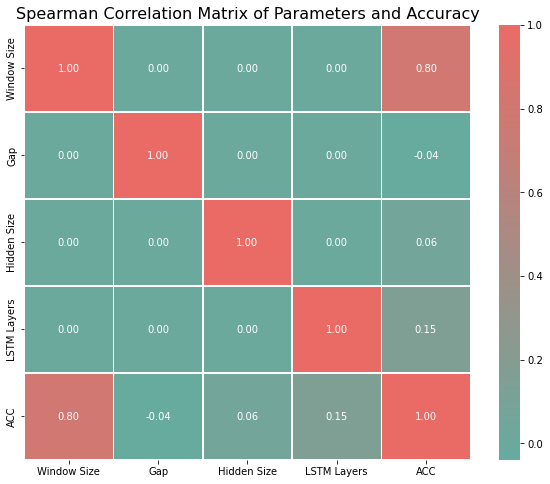

Highest Accuracy Recorded: 87.6712%

🎉 Analysis complete. All plots saved to '.analysis_output_64/'.


In [38]:
SEARCH_DIRECTORY = 'trained_models/' 
ANALYSIS_OUTPUT_DIRECTORY = '.analysis_output_64/'
print(f"🔍 Searching for folders containing '64' inside '{SEARCH_DIRECTORY}'...")
search_pattern = os.path.join(SEARCH_DIRECTORY, '**', '64', '*.csv')
csv_files_to_process = glob.glob(search_pattern, recursive=True)

if not csv_files_to_process:
    print(f"❌ No 'results.csv' files found inside folders containing '64'.")
    print(f"Please check the path '{SEARCH_DIRECTORY}' and your folder structure.")
else:
    print(f"✅ Found {len(csv_files_to_process)} result file(s) to analyze.")
    
    # Loop through each found file and call the analysis function
    for file_path in csv_files_to_process:
        print(file_path)
        if 'm1' in file_path: 
            threshold = .01 
        else: 
            threshold = .02

        analyze_hyperparameters(
            data_path=file_path, 
            save_path=ANALYSIS_OUTPUT_DIRECTORY,
            plot_show=True,  # Set to False to avoid opening many plot windows
            threshold= threshold     # Analyze models within 1.0% of the max accuracy
        )
        
    print(f"\n🎉 Analysis complete. All plots saved to '{ANALYSIS_OUTPUT_DIRECTORY}'.")


🔍 Searching for folders containing '64' inside 'trained_models/'...
✅ Found 18 result file(s) to analyze.
trained_models/franka_main/m2_cnnBiLSTM_contactDetection/64/hyperparameter_results.csv
             Window Size  Hidden Size  LSTM Layers       ACC
Window Size     1.000000     0.000000     0.000000  0.102915
Hidden Size     0.000000     1.000000     0.000000  0.040049
LSTM Layers     0.000000     0.000000     1.000000  0.054839
ACC             0.102915     0.040049     0.054839  1.000000
Highest Accuracy Recorded: 93.5544%
trained_models/franka_main/m2_cnnBiLSTM_contactLocalization/64/hyperparameter_results_localization.csv
             Window Size  Hidden Size  LSTM Layers       ACC
Window Size     1.000000      0.00000     0.000000  0.819137
Hidden Size     0.000000      1.00000     0.000000  0.207950
LSTM Layers     0.000000      0.00000     1.000000  0.023019
ACC             0.819137      0.20795     0.023019  1.000000
Highest Accuracy Recorded: 94.4918%
trained_models/franka_

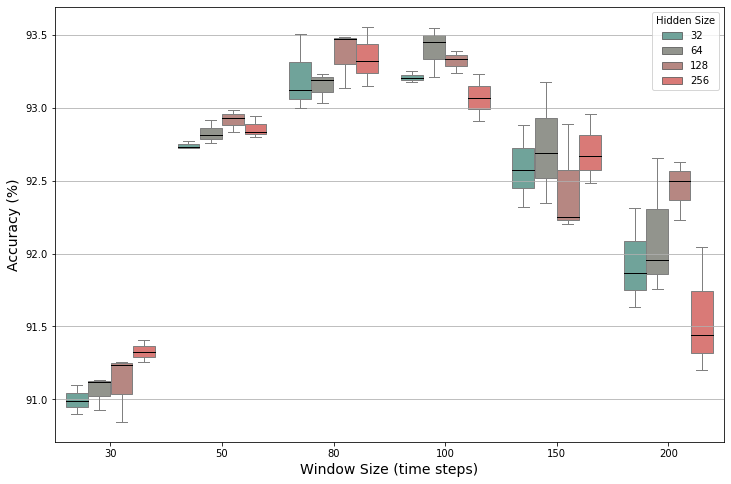

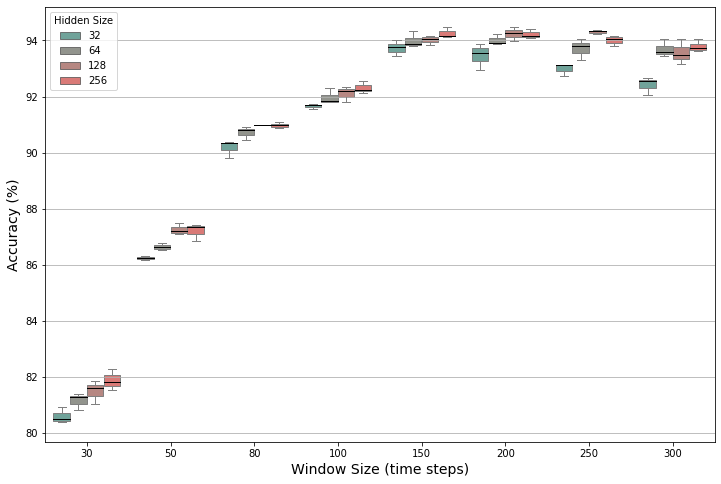

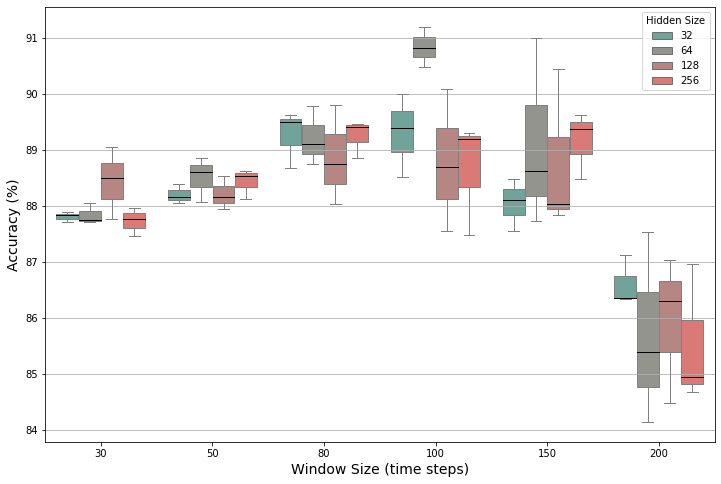

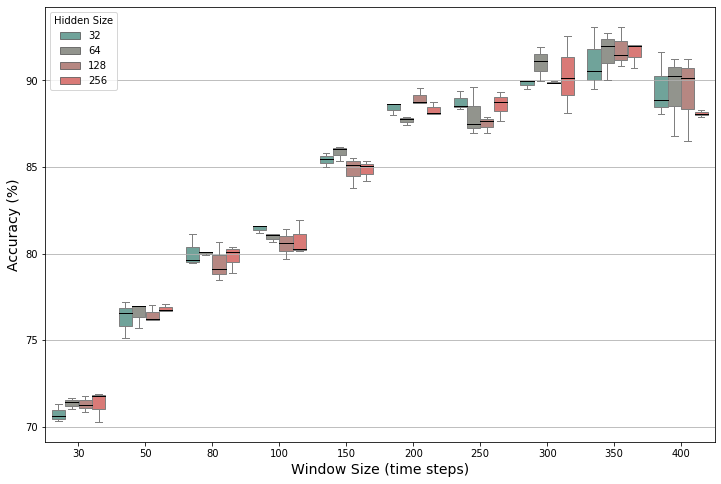

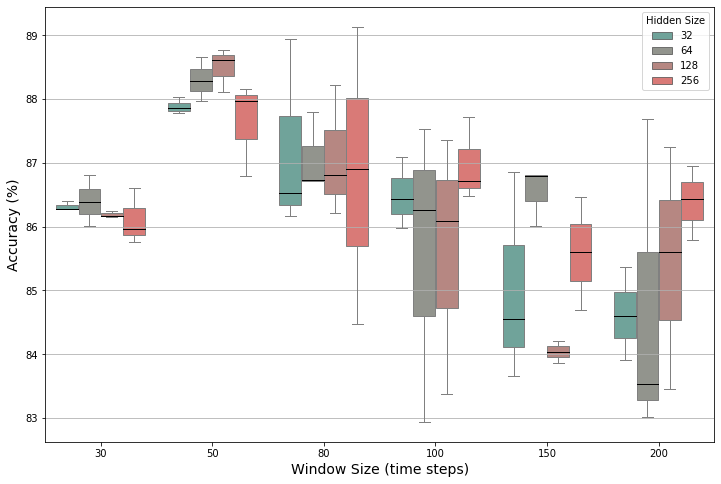

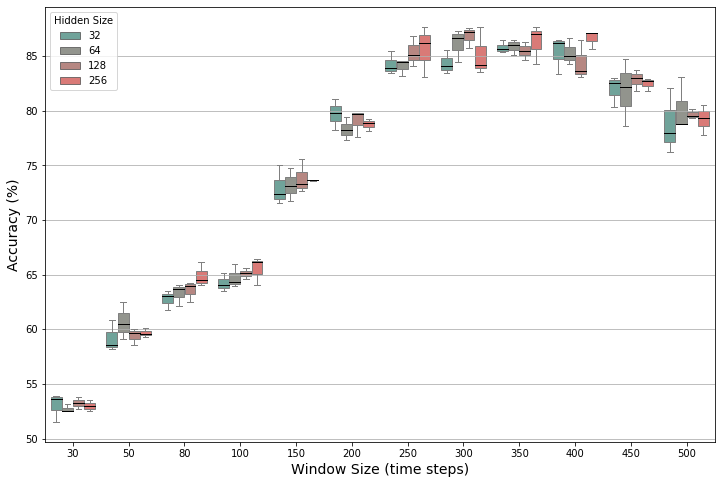

In [2]:
SEARCH_DIRECTORY = 'trained_models/' 
ANALYSIS_OUTPUT_DIRECTORY = '.analysis_cnnbilstm_64/'
print(f"🔍 Searching for folders containing '64' inside '{SEARCH_DIRECTORY}'...")
search_pattern = os.path.join(SEARCH_DIRECTORY, '**', '64', '*.csv')
csv_files_to_process = glob.glob(search_pattern, recursive=True)
csv_files_to_process = sorted(csv_files_to_process)
if not csv_files_to_process:
    print(f"❌ No 'results.csv' files found inside folders containing '64'.")
    print(f"Please check the path '{SEARCH_DIRECTORY}' and your folder structure.")
else:
    print(f"✅ Found {len(csv_files_to_process)} result file(s) to analyze.")
    
    # Loop through each found file and call the analysis function
    for file_path in csv_files_to_process:
        if 'cnn' in file_path and 'm2' in file_path:
            print(file_path)
            threshold = .02
            gap=1
            '''if 'main' in file_path:
                if 'localization' in file_path: 
                    window_size= 150
                else:
                    window_size = 80
            if 'mindlab' in file_path:
                if 'localization' in file_path: 
                    window_size= 350
                else:
                    window_size = 100
            if 'ur5' in file_path:
                if 'localization' in file_path: 
                    window_size= 300
                else:
                    window_size = 80'''
            analyze_hyperparameters(
                data_path=file_path, 
                save_path=ANALYSIS_OUTPUT_DIRECTORY,
                plot_show=False,  # Set to False to avoid opening many plot windows
                threshold= threshold,     # Analyze models within 1.0% of the max accuracy
                gap=gap
                #window_size = window_size
            )
        
    print(f"\n🎉 Analysis complete. All plots saved to '{ANALYSIS_OUTPUT_DIRECTORY}'.")


# Runetime dof = 7

Data loaded successfully:

Generating Plot 1: Combined Model Performance Distribution...


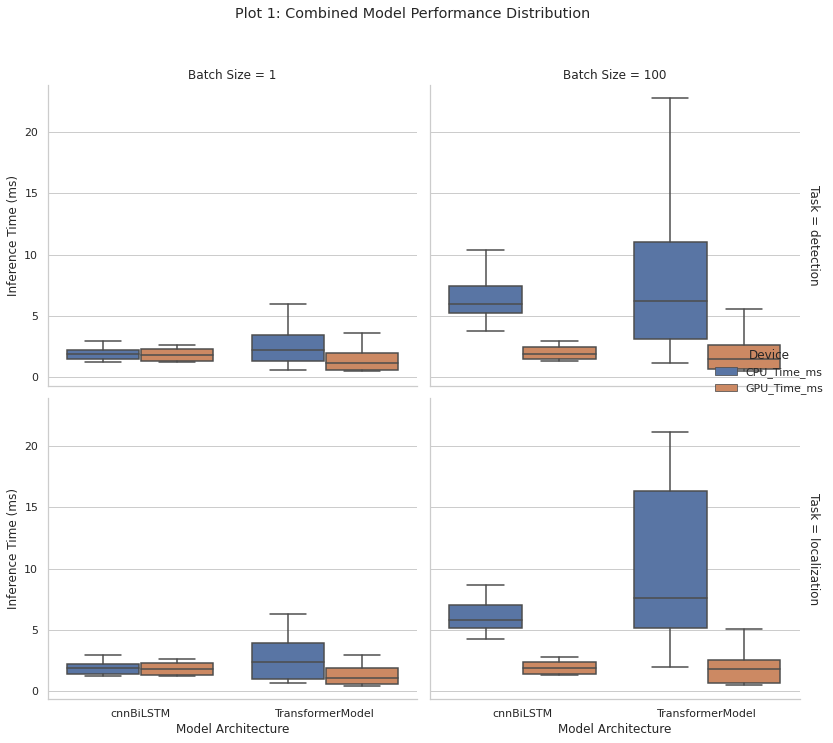

Generating Plot 2: Separated Impact of Window Size...
Generating Plot 3: Transformer-Only Complexity Analysis...


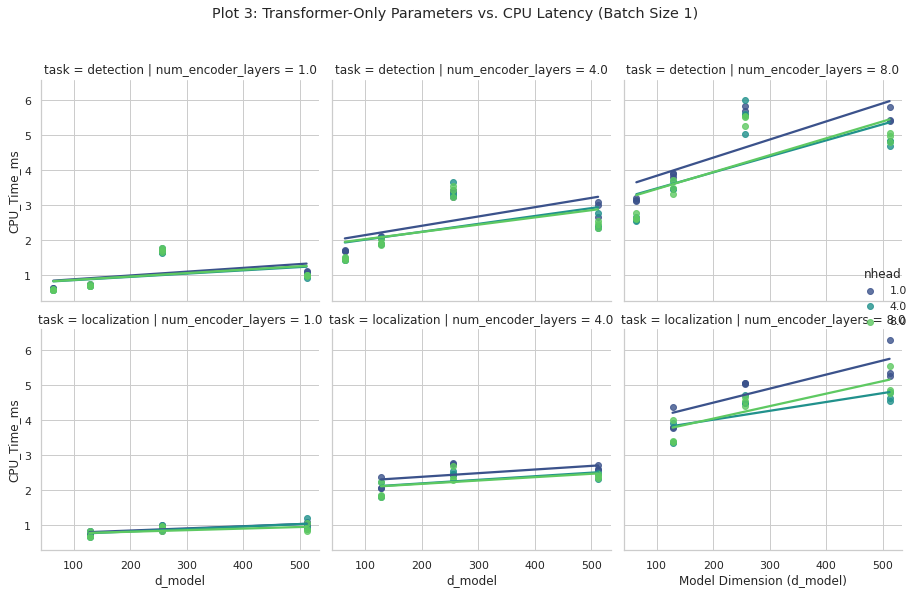

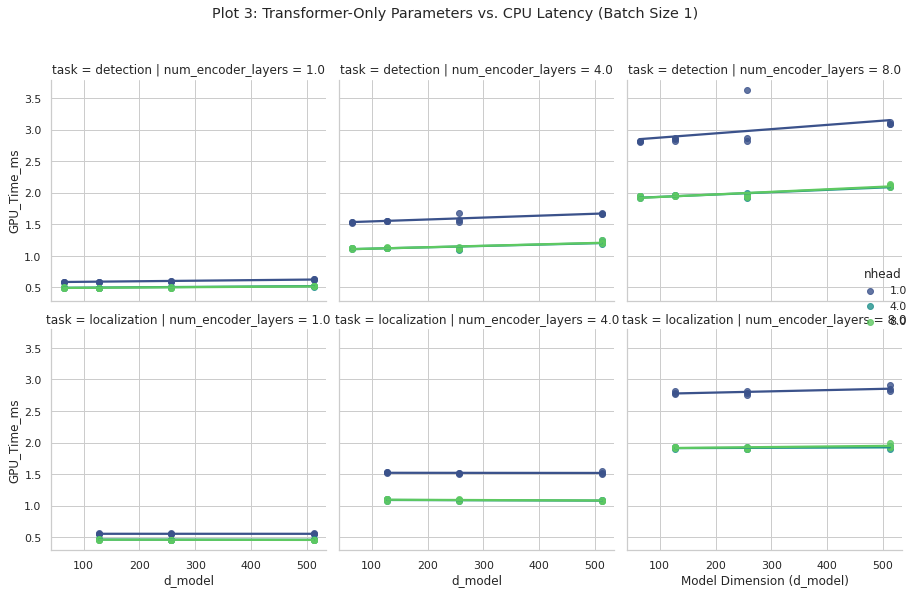

Generating Plot 3: CnnBiLSMT-Only Complexity Analysis...


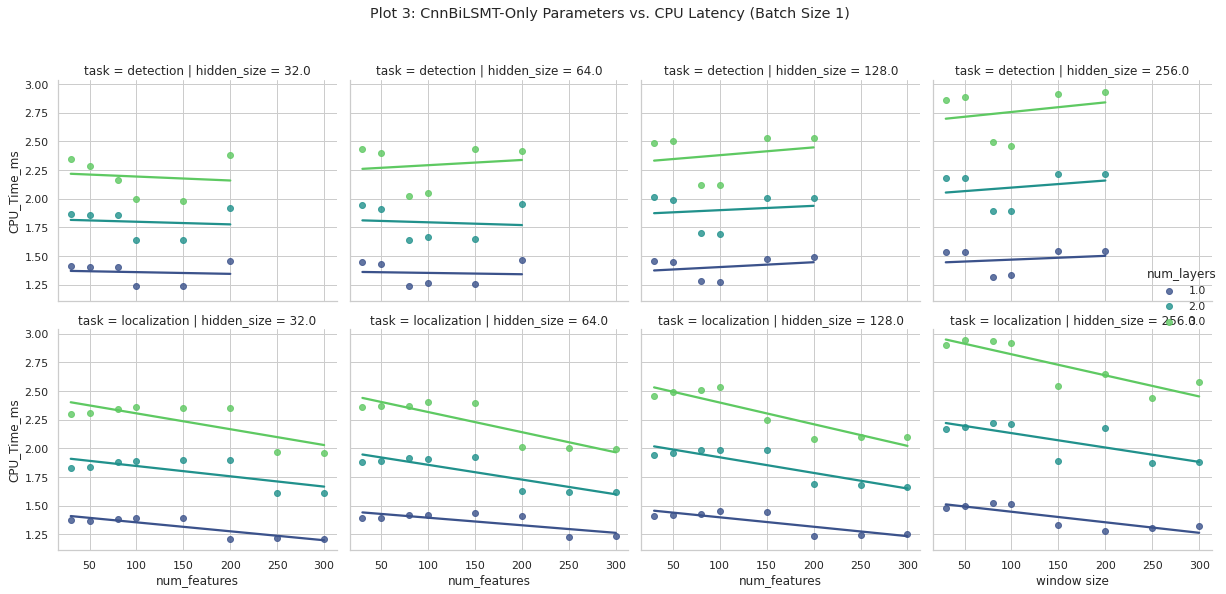

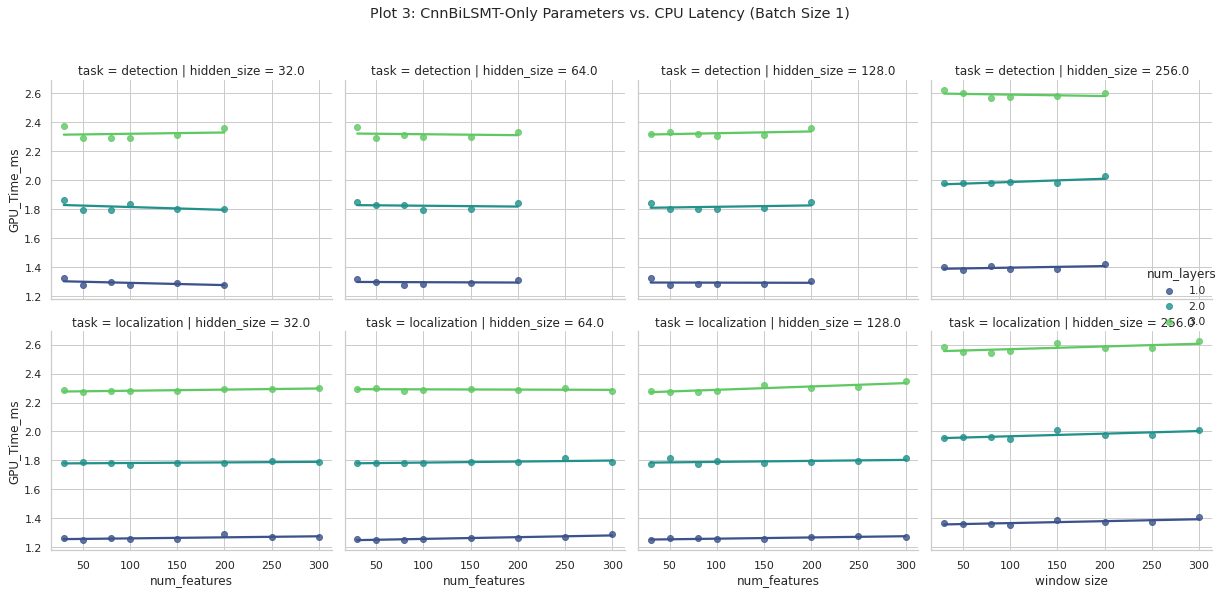

Generating Plot 4: Separated Top 5 Configurations...


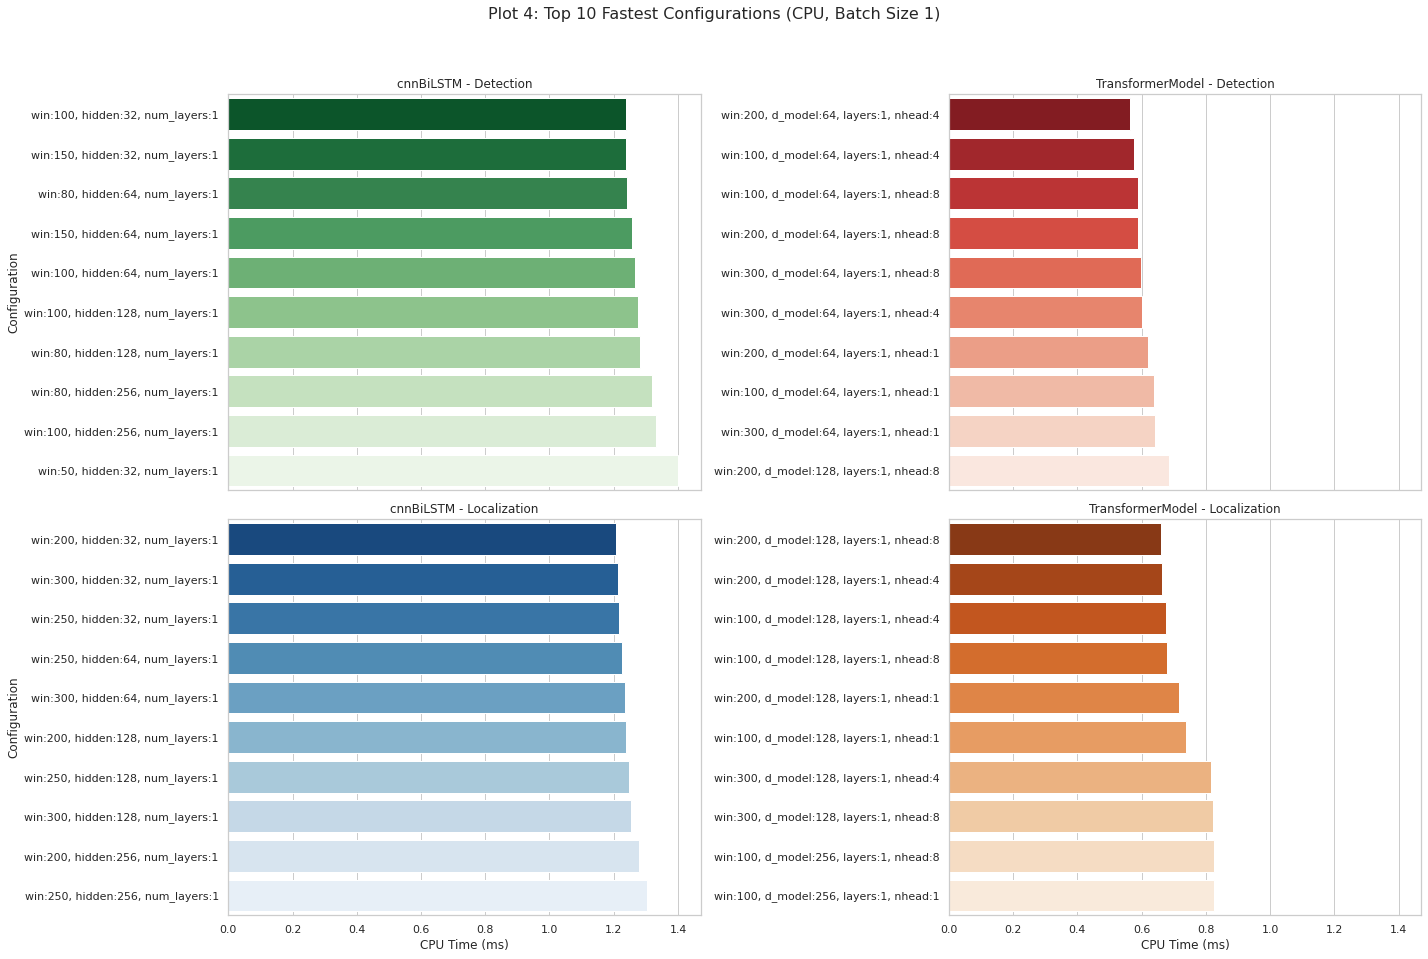

Generating Plot 4: Separated Top 5 Configurations...


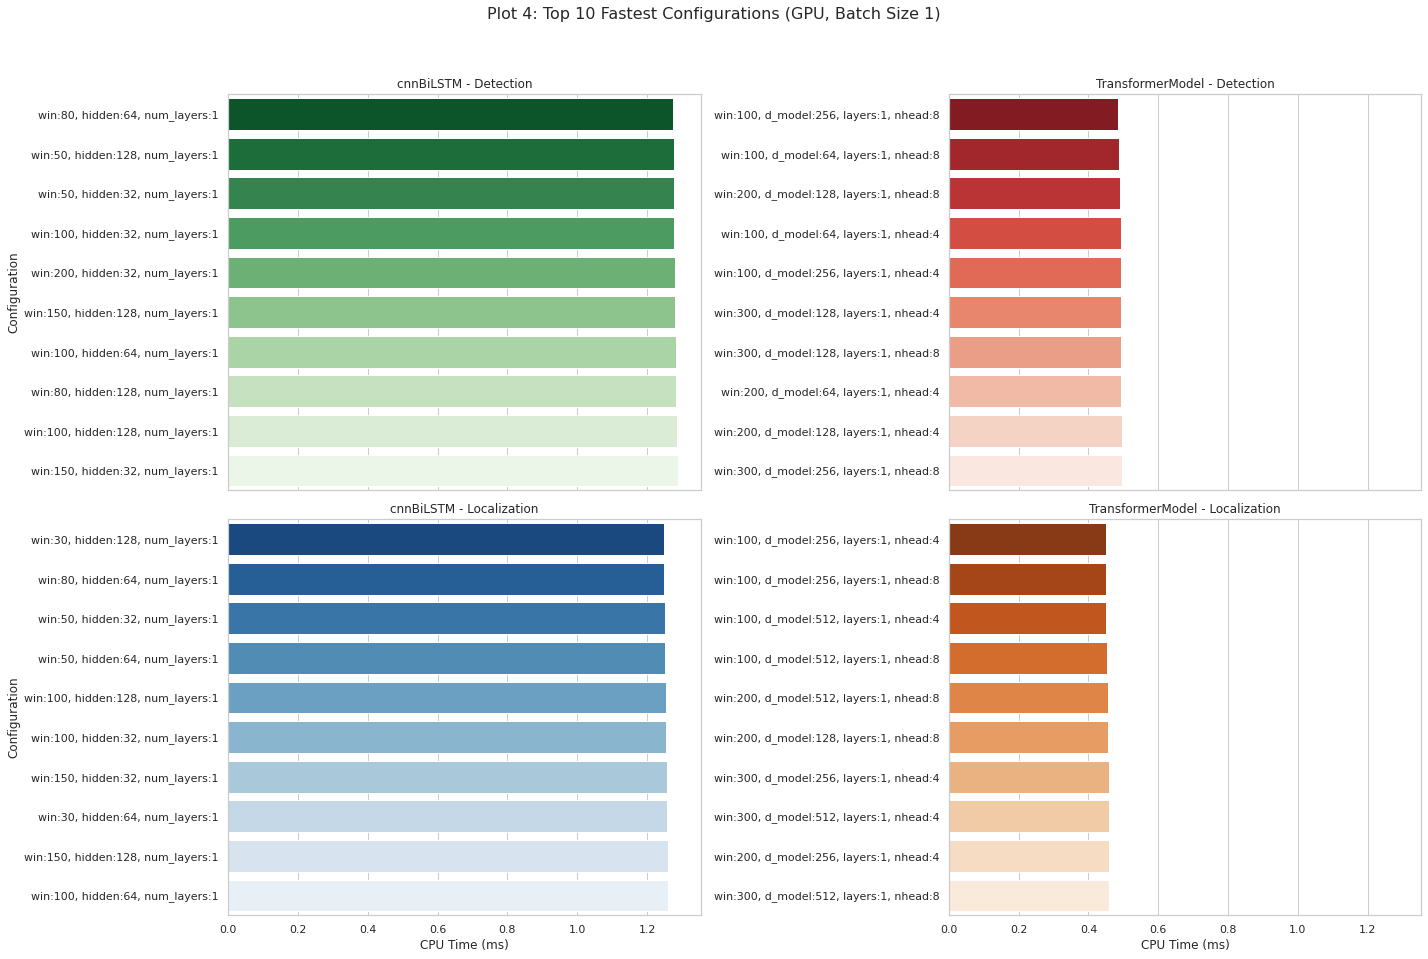


All visualizations complete.


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np # We'll need this for NaN handling

# Set a nice style for the plots
sns.set_theme(style="whitegrid")

# --- 1. Load Data ---
project_root = os.getcwd().replace('pipelines', '')
file_path = f'{project_root}/pipelines/trained_models/benchmark_results_dof7.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
    print("Please check the file path.")
    exit()

# Show all columns (useful for debugging)
pd.set_option('display.max_columns', None)
print("Data loaded successfully:")


# --- PLOT 1: High-Level COMBINED Box Plot ---
# (This plot is kept for high-level comparison)
print("\nGenerating Plot 1: Combined Model Performance Distribution...")

# Melt the DataFrame to plot CPU and GPU times together
id_cols = [col for col in df.columns if '_Time_ms' not in col] 
df_melt = df.melt(id_vars=id_cols, 
                  value_vars=['CPU_Time_ms', 'GPU_Time_ms'],
                  var_name='Device', 
                  value_name='Time (ms)')

g = sns.catplot(
    data=df_melt,
    x='Model',          
    y='Time (ms)',      
    hue='Device',       
    col='Batch_Size',   
    row='task',         
    kind='box',         
    showfliers=False,   
    margin_titles=True
)
g.set_axis_labels("Model Architecture", "Inference Time (ms)")
g.set_titles(col_template="Batch Size = {col_name}", row_template="Task = {row_name}")
plt.suptitle("Plot 1: Combined Model Performance Distribution", y=1.03)
plt.tight_layout()
plt.show()


# --- PLOT 2: SEPARATED Window Size Analysis (Batch Size 1) ---
print("Generating Plot 2: Separated Impact of Window Size...")
df_b1 = df[df['Batch_Size'] == 1].copy()

# --- Plot 2a: CNN-BiLSTM ---
df_b1_cnn = df_b1[df_b1['Model'] == 'cnnBiLSTM']

# --- Plot 2b: Transformer ---
df_b1_trans = df_b1[df_b1['Model'] == 'TransformerModel']

# --- PLOT 2: Transformer- Complexity Analysis ---
# (This plot is already separate, so it remains the same)
print("Generating Plot 3: Transformer-Only Complexity Analysis...")

if not df_b1_trans.empty:
    sns.lmplot(
        data=df_b1_trans,
        x='d_model',        
        y='CPU_Time_ms',
        hue='nhead',        
        col='num_encoder_layers', 
        row='task',         
        ci=None,
        palette='viridis',
        height=4
    )
    plt.suptitle("Plot 3: Transformer-Only Parameters vs. CPU Latency (Batch Size 1)", y=1.03)
    plt.xlabel("Model Dimension (d_model)")
    plt.ylabel("CPU Time (ms)")
    plt.tight_layout()
    plt.show()
    
    sns.lmplot(
        data=df_b1_trans,
        x='d_model',        
        y='GPU_Time_ms',
        hue='nhead',        
        col='num_encoder_layers', 
        row='task',         
        ci=None,
        palette='viridis',
        height=4
    )
    plt.suptitle("Plot 3: Transformer-Only Parameters vs. CPU Latency (Batch Size 1)", y=1.03)
    plt.xlabel("Model Dimension (d_model)")
    plt.ylabel("CPU Time (ms)")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Plot 3, no data found for 'TransformerModel'.")

# --- PLOT 3: cnnBiLSTM-Only Complexity Analysis ---
# (This plot is already separate, so it remains the same)
print("Generating Plot 3: CnnBiLSMT-Only Complexity Analysis...")

if not df_b1_trans.empty:
    sns.lmplot(
        data=df_b1_cnn,
        x='num_features',        
        y='CPU_Time_ms',
        hue='num_layers',        
        col='hidden_size', 
        row='task',         
        ci=None,
        palette='viridis',
        height=4
    )
    plt.suptitle("Plot 3: CnnBiLSMT-Only Parameters vs. CPU Latency (Batch Size 1)", y=1.03)
    plt.xlabel("window size")
    plt.ylabel("CPU Time (ms)")
    plt.tight_layout()
    plt.show()
    sns.lmplot(
        data=df_b1_cnn,
        x='num_features',        
        y='GPU_Time_ms',
        hue='num_layers',        
        col='hidden_size', 
        row='task',         
        ci=None,
        palette='viridis',
        height=4
    )
    plt.suptitle("Plot 3: CnnBiLSMT-Only Parameters vs. CPU Latency (Batch Size 1)", y=1.03)
    plt.xlabel("window size")
    plt.ylabel("CPU Time (ms)")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Plot 3, no data found for 'TransformerModel'.")
# --- PLOT 4: SEPARATED Top 10 Fastest Configurations ---
print("Generating Plot 4: Separated Top 5 Configurations...")

# Create a readable 'Config' label
param_cols = ['num_features', 'hidden_size', 'num_layers', 'd_model', 'num_encoder_layers', 'nhead']
df_b1['Config'] = df_b1.apply(
    lambda row: ", ".join(
        # Use short, clear labels
        f"{col.replace('num_encoder_layers', 'layers').replace('num_features', 'win').replace('hidden_size', 'hidden')}:{int(row[col])}" 
        for col in param_cols if pd.notna(row[col])
    ), 
    axis=1
)

# --- Create a 2x2 grid for the four categories ---
fig, axes = plt.subplots(2, 2, figsize=(20, 14), sharex=True)
fig.suptitle("Plot 4: Top 10 Fastest Configurations (CPU, Batch Size 1)", fontsize=16)

# --- 1. CNN - Detection ---
df_plot = df_b1[(df_b1['Model'] == 'cnnBiLSTM') & (df_b1['task'] == 'detection')].sort_values('CPU_Time_ms').head(10)
if not df_plot.empty:
    sns.barplot(ax=axes[0, 0], data=df_plot, x='CPU_Time_ms', y='Config', palette='Greens_r')
    axes[0, 0].set_title("cnnBiLSTM - Detection")
    axes[0, 0].set_ylabel("Configuration")
else:
    axes[0, 0].set_title("cnnBiLSTM - Detection (No Data)")
axes[0, 0].set_xlabel("")

# --- 2. Transformer - Detection ---
df_plot = df_b1[(df_b1['Model'] == 'TransformerModel') & (df_b1['task'] == 'detection')].sort_values('CPU_Time_ms').head(10)
if not df_plot.empty:
    sns.barplot(ax=axes[0, 1], data=df_plot, x='CPU_Time_ms', y='Config', palette='Reds_r')
    axes[0, 1].set_title("TransformerModel - Detection")
    axes[0, 1].set_ylabel("")
else:
    axes[0, 1].set_title("TransformerModel - Detection (No Data)")
axes[0, 1].set_xlabel("")

# --- 3. CNN - Localization ---
df_plot = df_b1[(df_b1['Model'] == 'cnnBiLSTM') & (df_b1['task'] == 'localization')].sort_values('CPU_Time_ms').head(10)
if not df_plot.empty:
    sns.barplot(ax=axes[1, 0], data=df_plot, x='CPU_Time_ms', y='Config', palette='Blues_r')
    axes[1, 0].set_title("cnnBiLSTM - Localization")
    axes[1, 0].set_ylabel("Configuration")
    axes[1, 0].set_xlabel("CPU Time (ms)")
else:
    axes[1, 0].set_title("cnnBiLSTM - Localization (No Data)")
    
# --- 4. Transformer - Localization ---
df_plot = df_b1[(df_b1['Model'] == 'TransformerModel') & (df_b1['task'] == 'localization')].sort_values('CPU_Time_ms').head(10)
if not df_plot.empty:
    sns.barplot(ax=axes[1, 1], data=df_plot, x='CPU_Time_ms', y='Config', palette='Oranges_r')
    axes[1, 1].set_title("TransformerModel - Localization")
    axes[1, 1].set_ylabel("")
    axes[1, 1].set_xlabel("CPU Time (ms)")
else:
    axes[1, 1].set_title("TransformerModel - Localization (No Data)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for suptitle
plt.show()


# --- PLOT 4: SEPARATED Top 10 Fastest Configurations ---
print("Generating Plot 4: Separated Top 5 Configurations...")

# Create a readable 'Config' label
param_cols = ['num_features', 'hidden_size', 'num_layers', 'd_model', 'num_encoder_layers', 'nhead']
df_b1['Config'] = df_b1.apply(
    lambda row: ", ".join(
        # Use short, clear labels
        f"{col.replace('num_encoder_layers', 'layers').replace('num_features', 'win').replace('hidden_size', 'hidden')}:{int(row[col])}" 
        for col in param_cols if pd.notna(row[col])
    ), 
    axis=1
)

# --- Create a 2x2 grid for the four categories ---
fig, axes = plt.subplots(2, 2, figsize=(20, 14), sharex=True)
fig.suptitle("Plot 4: Top 10 Fastest Configurations (GPU, Batch Size 1)", fontsize=16)

# --- 1. CNN - Detection ---
df_plot = df_b1[(df_b1['Model'] == 'cnnBiLSTM') & (df_b1['task'] == 'detection')].sort_values('GPU_Time_ms').head(10)
if not df_plot.empty:
    sns.barplot(ax=axes[0, 0], data=df_plot, x='GPU_Time_ms', y='Config', palette='Greens_r')
    axes[0, 0].set_title("cnnBiLSTM - Detection")
    axes[0, 0].set_ylabel("Configuration")
else:
    axes[0, 0].set_title("cnnBiLSTM - Detection (No Data)")
axes[0, 0].set_xlabel("")

# --- 2. Transformer - Detection ---
df_plot = df_b1[(df_b1['Model'] == 'TransformerModel') & (df_b1['task'] == 'detection')].sort_values('GPU_Time_ms').head(10)
if not df_plot.empty:
    sns.barplot(ax=axes[0, 1], data=df_plot, x='GPU_Time_ms', y='Config', palette='Reds_r')
    axes[0, 1].set_title("TransformerModel - Detection")
    axes[0, 1].set_ylabel("")
else:
    axes[0, 1].set_title("TransformerModel - Detection (No Data)")
axes[0, 1].set_xlabel("")

# --- 3. CNN - Localization ---
df_plot = df_b1[(df_b1['Model'] == 'cnnBiLSTM') & (df_b1['task'] == 'localization')].sort_values('GPU_Time_ms').head(10)
if not df_plot.empty:
    sns.barplot(ax=axes[1, 0], data=df_plot, x='GPU_Time_ms', y='Config', palette='Blues_r')
    axes[1, 0].set_title("cnnBiLSTM - Localization")
    axes[1, 0].set_ylabel("Configuration")
    axes[1, 0].set_xlabel("CPU Time (ms)")
else:
    axes[1, 0].set_title("cnnBiLSTM - Localization (No Data)")
    
# --- 4. Transformer - Localization ---
df_plot = df_b1[(df_b1['Model'] == 'TransformerModel') & (df_b1['task'] == 'localization')].sort_values('GPU_Time_ms').head(10)
if not df_plot.empty:
    sns.barplot(ax=axes[1, 1], data=df_plot, x='GPU_Time_ms', y='Config', palette='Oranges_r')
    axes[1, 1].set_title("TransformerModel - Localization")
    axes[1, 1].set_ylabel("")
    axes[1, 1].set_xlabel("CPU Time (ms)")
else:
    axes[1, 1].set_title("TransformerModel - Localization (No Data)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for suptitle
plt.show()

print("\nAll visualizations complete.")

# best model with runtime consideration

In [41]:
import pandas as pd
import os
import sys # Added for more robust error handling

def analyze_best_model(file_path: str):
    """
    Loads a CSV file and reports the single best-performing model based
    on specific criteria for either 'lstm' or 'transformer'.

    Args:
        file_path (str): The direct path to the CSV file.
        model_type (str): The type of model to analyze ('lstm' or 'transformer').
    """
    
    # --- 1. Load Data ---
    if 'transformer' in file_path:
        model_type = 'transformer'
    else:
        model_type = 'lstm'
    #print(f"\n--- Analysis for {model_type.upper()}: {file_path} ---")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return
    except Exception as e:
        print(f"Error loading CSV file: {e}")
        return

    # --- 2. Define Columns and Filters based on Model Type ---
    acc_col = 'ACC'
    required_cols = [acc_col]
    df_filtered = pd.DataFrame()
    report_string = ""

    try:
        if model_type == 'lstm':
            # --- LSTM Logic ---
            layer_col = 'num_layer'
            required_cols.append(layer_col)
            
            # Check if all required columns exist
            if not set(required_cols).issubset(df.columns):
                print(f"Error: DataFrame is missing required columns. Needs: {required_cols}")
                return

            # Apply filter
            df_filtered = df[df[layer_col] == 1]
            report_string = f"🥇 Best Model with {layer_col} == 1 (Highest Accuracy):"

        elif model_type == 'transformer':
            # --- Transformer Logic ---
            # Use 'num_encoder_layers' if it exists, otherwise fall back to 'num_layer'
            layer_col = 'num_layer'
            head_col = 'n_head'
            required_cols.extend([layer_col, head_col])

            # Check if all required columns exist
            if not set(required_cols).issubset(df.columns):
                print(f"Error: DataFrame is missing required columns. Needs: {required_cols}")
                return
            
            # Define the filters
            condition_layers = df[layer_col] == 1
            condition_heads = df[head_col].isin([4, 8])
            
            # Apply filters
            df_filtered = df[condition_layers & condition_heads]
            report_string = f"🥇 Best Model with {layer_col} == 1 AND {head_col} in [4, 8] (Highest Accuracy):"

        else:
            print(f"Error: Unknown model_type '{model_type}'. Please use 'lstm' or 'transformer'.")
            return
            
    except KeyError as e:
        print(f"Error: A required column is missing from the CSV. Details: {e}", file=sys.stderr)
        return
    except Exception as e:
        print(f"An error occurred during filtering: {e}", file=sys.stderr)
        return

    # --- 3. Find Best Model and Report ---
    if df_filtered.empty:
        print("No models found matching the specified criteria.")
        return
        
    try:
        # Find the row with the maximum accuracy from the filtered group
        best_model_row = df_filtered.loc[df_filtered[acc_col].idxmax()]
        
        print(f"\n{report_string}")
        
        # Convert the Series to a DataFrame for cleaner printing
        print(best_model_row.to_frame().T.to_string())

    except Exception as e:
        print(f"An error occurred during final analysis: {e}")

In [43]:
SEARCH_DIRECTORY = 'trained_models/' 
ANALYSIS_OUTPUT_DIRECTORY = '.analysis_cnnbilstm_64_v1/'
print(f"🔍 Searching for folders containing '64' inside '{SEARCH_DIRECTORY}'...")
search_pattern = os.path.join(SEARCH_DIRECTORY, '**', '64', '*.csv')
csv_files_to_process = glob.glob(search_pattern, recursive=True)
csv_files_to_process = sorted(csv_files_to_process)
if not csv_files_to_process:
    print(f"❌ No 'results.csv' files found inside folders containing '64'.")
    print(f"Please check the path '{SEARCH_DIRECTORY}' and your folder structure.")
else:
    print(f"✅ Found {len(csv_files_to_process)} result file(s) to analyze.")
    
    # Loop through each found file and call the analysis function
    for file_path in csv_files_to_process:
        if 'transformer' in file_path:
            print(file_path)
            threshold = .02
            gap=1
            analyze_best_model(
                file_path=file_path, 
            )
        
    for file_path in csv_files_to_process:
        if 'cnn' in file_path and 'm2' in file_path:
            print(file_path)
            threshold = .02
            gap=1
            analyze_best_model(
                file_path=file_path, 
            )



🔍 Searching for folders containing '64' inside 'trained_models/'...
✅ Found 18 result file(s) to analyze.
trained_models/franka_main/m2_transformer_contactDetection/64/hyperparameter_results_expanded.csv

🥇 Best Model with num_layer == 1 AND n_head in [4, 8] (Highest Accuracy):
    seq_num  d_model  n_head  num_layer  dropout  learning_rate  weight_decay        ACC
59    200.0    128.0     8.0        1.0      0.3         0.0001        0.0001  92.947741
trained_models/franka_main/m2_transformer_contactLocalization/64/hyperparameter_results_localization.csv

🥇 Best Model with num_layer == 1 AND n_head in [4, 8] (Highest Accuracy):
    seq_num  gap  d_model  n_head  num_layer  dropout        ACC  train_size  val_size
51    200.0  1.0    512.0     8.0        1.0      0.3  84.398984   1023017.0   92481.0
trained_models/franka_mindlab/m2_transformer_contactDetection/64/hyperparameter_results_expanded.csv

🥇 Best Model with num_layer == 1 AND n_head in [4, 8] (Highest Accuracy):
    seq_num  